#  ML for GNSS Velocity Prediction
## Crustal Ground Deformation & Strain Analysis in Mindanao, Philippines

---
**Authors:** J.K. Fernandez · E.M. Gohetia · J.S. Sexcion  
**Data:** PAGeNet / UNR Geodetic Laboratory (Blewitt et al., 2018)


## BLOCK 1 — INSTALL DEPENDENCIES

In [29]:
!pip install pykrige --quiet
!pip install scikit-learn --upgrade --quiet

## BLOCK 2 — IMPORTS & GLOBAL SETTINGS

In [30]:
import warnings
warnings.filterwarnings('ignore')

import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# Sklearn
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    classification_report, accuracy_score,
    precision_score, recall_score, f1_score
)

# TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# PyKrige
try:
    from pykrige.ok import OrdinaryKriging
    PYKRIGE_AVAILABLE = True
    print("PyKrige loaded successfully.")
except ImportError:
    PYKRIGE_AVAILABLE = False
    print("PyKrige not found — IDW will be used as fallback.")

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

# Thesis-style plots
plt.rcParams.update({
    'figure.dpi'      : 150,
    'font.family'     : 'serif',
    'font.size'       : 11,
    'axes.titlesize'  : 13,
    'axes.labelsize'  : 11,
    'legend.fontsize' : 9,
    'axes.grid'       : True,
    'grid.alpha'      : 0.3,
    'figure.facecolor': 'white',
})

MODEL_COLORS = {
    'Random Forest': '#2196F3',
    'SVR'          : '#FF9800',
    'LSTM'         : '#4CAF50',
}

print("All imports done.")
print(f"TensorFlow version : {tf.__version__}")

PyKrige loaded successfully.
All imports done.
TensorFlow version : 2.20.0


## BLOCK 3 — LOAD & COMBINE ALL STATION XLSX FILES

In [31]:
csv_directory = '/content/sample_data/'
xlsx_files    = glob.glob(csv_directory + '*.xlsx')

list_df = []
for file in xlsx_files:
    try:
        df_temp = pd.read_excel(file)
        list_df.append(df_temp)
        print(f"  Read: {file}  →  {df_temp.shape}")
    except Exception as e:
        print(f"  ERROR reading {file}: {e}")

if not list_df:
    raise ValueError("No XLSX files found. Check your directory path.")

combined_df = pd.concat(list_df, ignore_index=True)
print(f"\nCombined shape : {combined_df.shape}")
print(f"Raw columns    : {list(combined_df.columns)}")

  Read: /content/sample_data/PTGO.xlsx  →  (280, 23)
  Read: /content/sample_data/DVAO.xlsx  →  (2980, 23)
  Read: /content/sample_data/PDIP.xlsx  →  (211, 23)
  Read: /content/sample_data/PMAI.xlsx  →  (7, 23)
  Read: /content/sample_data/PBIS.xlsx  →  (71, 23)
  Read: /content/sample_data/PDAV.xlsx  →  (265, 23)
  Read: /content/sample_data/PCOT.xlsx  →  (125, 23)
  Read: /content/sample_data/PTCG.xlsx  →  (14, 23)
  Read: /content/sample_data/PGEN.xlsx  →  (2373, 23)
  Read: /content/sample_data/PSUR.xlsx  →  (714, 23)
  Read: /content/sample_data/PDDN.xlsx  →  (49, 23)
  Read: /content/sample_data/PMRM.xlsx  →  (22, 23)
  Read: /content/sample_data/PZAM.xlsx  →  (284, 23)

Combined shape : (7395, 23)
Raw columns    : ['site', 'YYMMMDD', 'yyyy.yyyy', '__MJD', 'week', 'd', 'reflon', '_e0(m)', '__east(m)', '____n0(m)', '_north(m)', 'u0(m)', '____up(m)', '_ant(m)', 'sig_e(m)', 'sig_n(m)', 'sig_u(m)', '__corr_en', '__corr_eu', '__corr_nu', '_latitude(deg)', '_longitude(deg)', '__height(

## BLOCK 4 — PREPROCESSING

In [32]:
df = combined_df.copy()

# ── 1. Clean column names ──────────────────────────────────────
df.columns = df.columns.str.strip().str.lower()
new_columns = []
for col in df.columns:
    col = col.replace('__', '')
    col = col.replace('(m)', '')
    col = col.replace('(deg)', '')
    col = col.replace('.', '')
    col = col.strip('_')
    new_columns.append(col)
df.columns = new_columns
print("Cleaned columns:")
print(list(df.columns))

if 'longitude' in df.columns:
    df['longitude'] = df['longitude'] % 360
    # print(f"\nBug 3 Fixed — Longitude: {df['longitude'].min():.4f} → {df['longitude'].max():.4f} °E")

if 'height' in df.columns:
    df['height'] = pd.to_numeric(df['height'], errors='coerce')

if 'yyyyyyyy' in df.columns:
    df = df.rename(columns={'yyyyyyyy': 'decimal_year'})
elif 'yymmmdd' in df.columns:
    df = df.rename(columns={'yymmmdd': 'decimal_year'})

# ── 5. Keep only pipeline-relevant columns (REMOVED Vu/sig_u) ─────────────────────
pipeline_cols = [
    'site', 'decimal_year', 'mjd', 'week', 'east', 'north',
    'sig_e', 'sig_n', 'corr_en', 'latitude', 'longitude', 'height'
]
pipeline_cols = [c for c in pipeline_cols if c in df.columns]
df = df[pipeline_cols]

df = df.drop_duplicates()
critical = ['site', 'mjd', 'decimal_year', 'east', 'north', 'latitude', 'longitude']
df = df.dropna(subset=critical)

numeric_cols = df.select_dtypes(include=np.number).columns
for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

MIN_EPOCHS = 49 #suppose 50 but e 49 nlng pra maapil pa PDDN (DavNor)
epoch_counts = df.groupby('site').size()
valid_sites = epoch_counts[epoch_counts >= MIN_EPOCHS].index
df = df[df['site'].isin(valid_sites)].reset_index(drop=True)

def zscore_filter_site(group, cols, threshold=3):
    mask = pd.Series(True, index=group.index)
    for col in cols:
        z = np.abs(stats.zscore(group[col].values))
        mask &= (z < threshold)
    return group[mask]

df = df.groupby('site', group_keys=False).apply(zscore_filter_site, cols=['east', 'north'])
df = df.sort_values(['site', 'mjd']).reset_index(drop=True)
display(df.head())
df.to_csv("preprocessed_gnss_data.csv", index=False)

for comp in ['east', 'north']:
    df[comp] = (
        df.groupby('site')[comp]
        .transform(lambda x: x.rolling(7, center=True, min_periods=1).median())
    )

Cleaned columns:
['site', 'yymmmdd', 'yyyyyyyy', 'mjd', 'week', 'd', 'reflon', 'e0', 'east', 'n0', 'north', 'u0', 'up', 'ant', 'sig_e', 'sig_n', 'sig_u', 'corr_en', 'corr_eu', 'corr_nu', 'latitude', 'longitude', 'height']


,site,decimal_year,mjd,week,east,north,sig_e,sig_n,corr_en,latitude,longitude,height
0,DVAO,2015.3676,57157,1844,0.885038,0.147227,0.000888,0.000769,-0.078897,7.071865,125.61287,99.98542
1,DVAO,2015.5537,57225,1854,0.879199,0.148954,0.000975,0.000821,-0.050645,7.071865,125.61287,99.95571
2,DVAO,2015.5784,57234,1855,0.878102,0.151485,0.000849,0.000757,-0.081728,7.071865,125.61287,99.96140
3,DVAO,2016.0411,57403,1879,0.867190,0.144569,0.000799,0.000714,-0.034633,7.071865,125.61287,99.95622
4,DVAO,2016.0438,57404,1880,0.866734,0.143623,0.000797,0.000708,-0.031813,7.071865,125.61287,99.95258


## BLOCK 5: VELOCITY COMPUTATION

In [33]:
from sklearn.linear_model import LinearRegression

WINDOW = 30

print("=" * 60)
print("BLOCK — VELOCITY COMPUTATION USING ROLLING LINEAR REGRESSION")
print("=" * 60)
print(f"Rolling Window Size: {WINDOW} epochs")
print("Computing East Velocity (Ve) and North Velocity (Vn)...\n")

velocity_rows = []
site_summary = []

for site_id, grp in df.groupby('site'):

    grp = grp.sort_values('mjd').reset_index(drop=True)

    if len(grp) < WINDOW:
        continue

    computed_count = 0

    for i in range(WINDOW, len(grp)):

        sub = grp.iloc[i-WINDOW:i]

        # Time variable
        t = sub['decimal_year'].values.reshape(-1,1)

        # Linear regression for East and North components
        ve_model = LinearRegression().fit(t, sub['east'])
        vn_model = LinearRegression().fit(t, sub['north'])

        # Store current row with computed velocities
        row = grp.iloc[i].copy()
        row['Ve'] = ve_model.coef_[0]
        row['Vn'] = vn_model.coef_[0]

        velocity_rows.append(row)
        computed_count += 1

    site_summary.append({
        'Site': site_id,
        'Epochs': len(grp),
        'Computed_Velocities': computed_count
    })

# Final DataFrame
vel_df = pd.DataFrame(velocity_rows)

print("=" * 60)
print("VELOCITY COMPUTATION SUMMARY")
print("=" * 60)

summary_df = pd.DataFrame(site_summary)

if not summary_df.empty:
    display(summary_df)
else:
    print("No valid sites processed.")

print("\nFinal Velocity Dataset Shape:", vel_df.shape)
print("Columns:", vel_df.columns.tolist())

BLOCK — VELOCITY COMPUTATION USING ROLLING LINEAR REGRESSION
Rolling Window Size: 30 epochs
Computing East Velocity (Ve) and North Velocity (Vn)...

VELOCITY COMPUTATION SUMMARY


,Site,Epochs,Computed_Velocities
0,DVAO,2980,2950
1,PBIS,71,41
2,PCOT,125,95
3,PDAV,257,227
4,PDDN,49,19
5,PDIP,201,171
6,PGEN,2366,2336
7,PSUR,693,663
8,PTGO,268,238
9,PZAM,277,247



Final Velocity Dataset Shape: (6987, 14)
Columns: ['site', 'decimal_year', 'mjd', 'week', 'east', 'north', 'sig_e', 'sig_n', 'corr_en', 'latitude', 'longitude', 'height', 'Ve', 'Vn']


## BLOCK 6: FEATURE ENGINEERING

In [34]:
from sklearn.neighbors import NearestNeighbors
coords = vel_df[['latitude', 'longitude']].values
nn = NearestNeighbors(n_neighbors=5)
nn.fit(coords)
distances, indices = nn.kneighbors(coords)
neighbor_Ve = []; neighbor_Vn = []
for idxs in indices:
    neighbor_Ve.append(vel_df.iloc[idxs]['Ve'].mean())
    neighbor_Vn.append(vel_df.iloc[idxs]['Vn'].mean())
vel_df['neighbor_Ve'] = neighbor_Ve
vel_df['neighbor_Vn'] = neighbor_Vn

center_lat = vel_df['latitude'].mean()
center_lon = vel_df['longitude'].mean()

vel_df['dlat_center'] = vel_df['latitude'] - center_lat
vel_df['dlon_center'] = vel_df['longitude'] - center_lon

vel_df['radial_dist'] = np.sqrt(
    vel_df['dlat_center']**2 +
    vel_df['dlon_center']**2
)

from sklearn.preprocessing import LabelEncoder, StandardScaler

# 1. Coordinate Offsets and Radial Distance
center_lat = vel_df['latitude'].mean()
center_lon = vel_df['longitude'].mean()
vel_df['dlat_center'] = vel_df['latitude'] - center_lat
vel_df['dlon_center'] = vel_df['longitude'] - center_lon
vel_df['radial_dist'] = np.sqrt(vel_df['dlat_center']**2 + vel_df['dlon_center']**2)

# 2. Encoding and Lags (Ensure all components are represented to match model shape)
le = LabelEncoder()
vel_df['site_encoded'] = le.fit_transform(vel_df['site'])

# Note: Even if we focus on Ve/Vn, the model architecture requires the original feature count
lag_steps = 3
for lag in range(1, lag_steps + 1):
    vel_df[f'Ve_lag{lag}'] = vel_df.groupby('site')['Ve'].shift(lag)
    vel_df[f'Vn_lag{lag}'] = vel_df.groupby('site')['Vn'].shift(lag)

# Drop NaNs from lagging
vel_df = vel_df.dropna().reset_index(drop=True)

feature_cols = [
    'latitude', 'longitude', 'height', 'decimal_year', 'mjd', 'sig_e', 'sig_n', 'corr_en',
    'site_encoded', 'neighbor_Ve', 'neighbor_Vn', 'dlat_center', 'dlon_center', 'radial_dist',
    'Ve_lag1', 'Ve_lag2', 'Ve_lag3', 'Vn_lag1', 'Vn_lag2', 'Vn_lag3'
]

scaler = StandardScaler()
print(f'Feature engineering complete. Shape before sort: {vel_df.shape}')

Feature engineering complete. Shape before sort: (6957, 26)


## BLOCK 7: DATA SPLITTING (80 / 20)

In [35]:
# ── Sort FIRST, THEN build X and y so they always match ──
vel_df = vel_df.sort_values('mjd').reset_index(drop=True)

X  = vel_df[feature_cols]
y  = vel_df[['Ve', 'Vn']]
Xs = scaler.fit_transform(X)

# Split using the continuous time index (MJD)
split_mjd = vel_df['mjd'].quantile(0.80)
train_mask = vel_df['mjd'] <= split_mjd
test_mask  = vel_df['mjd'] > split_mjd

X_train = Xs[train_mask]
X_test  = Xs[test_mask]
y_train = y[train_mask].reset_index(drop=True)
y_test  = y[test_mask].reset_index(drop=True)

print(f"Train samples : {X_train.shape[0]}  |  Test samples : {X_test.shape[0]}")
print(f"y_train Ve — mean: {y_train['Ve'].mean():.5f} m/yr, std: {y_train['Ve'].std():.5f}")
print(f"y_test  Ve — mean: {y_test['Ve'].mean():.5f}  m/yr, std: {y_test['Ve'].std():.5f}")

Train samples : 5566  |  Test samples : 1391
y_train Ve — mean: -0.02737 m/yr, std: 0.08332
y_test  Ve — mean: -0.00976  m/yr, std: 0.03739


## BLOCK 8 — PHASE A: RANDOM FOREST

  OOB R²         : 0.9845
  Test R²        : 0.6713

  Feature Importances:
Vn_lag1         0.2098
Ve_lag1         0.1676
neighbor_Vn     0.1221
Vn_lag2         0.1205
Ve_lag2         0.1113
neighbor_Ve     0.1001
Ve_lag3         0.0591
Vn_lag3         0.0466
height          0.0134
mjd             0.0123
dlat_center     0.0093
decimal_year    0.0078
latitude        0.0073
sig_n           0.0033
sig_e           0.0033
radial_dist     0.0024
dlon_center     0.0014
longitude       0.0010
site_encoded    0.0008
corr_en         0.0006


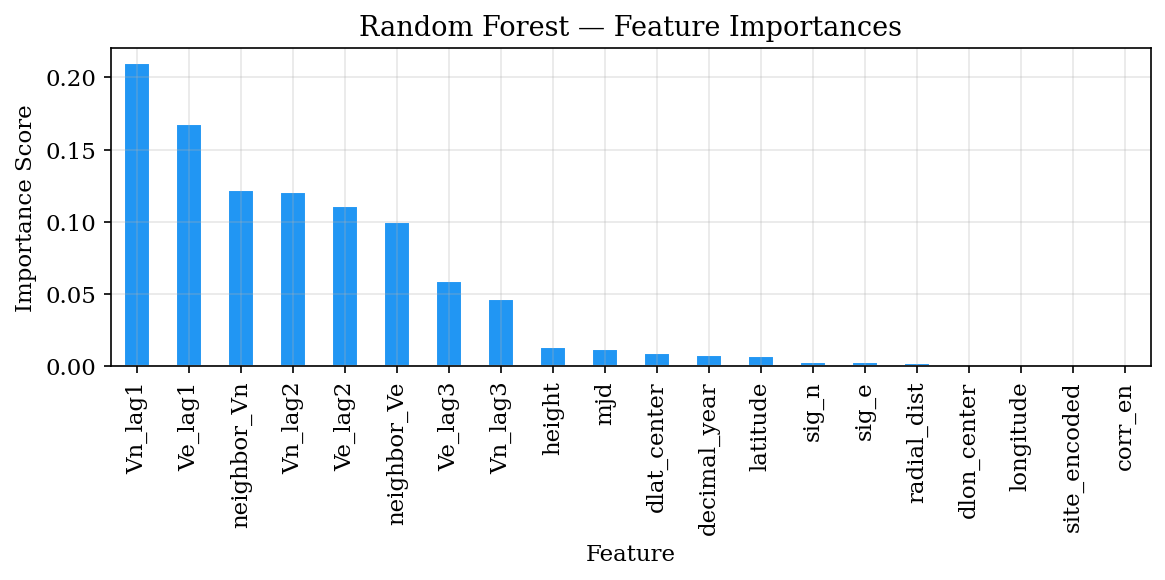

Saved: rf_feature_importance.png


In [36]:
rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    min_samples_split=4,
    min_samples_leaf=2,
    max_features='sqrt',
    oob_score=True,
    n_jobs=-1,
    random_state=RANDOM_STATE,
)
rf_model.fit(X_train, y_train)

rf_oob    = rf_model.oob_score_
rf_test   = rf_model.predict(X_test)
rf_test_r2 = r2_score(y_test, rf_test)

print(f"  OOB R²         : {rf_oob:.4f}")
print(f"  Test R²        : {rf_test_r2:.4f}")

importances = pd.Series(
    rf_model.feature_importances_, index=feature_cols
).sort_values(ascending=False)
print("\n  Feature Importances:")
print(importances.round(4).to_string())

fig, ax = plt.subplots(figsize=(8, 4))
importances.plot(kind='bar', ax=ax, color='#2196F3', edgecolor='white')
ax.set_title("Random Forest — Feature Importances")
ax.set_ylabel("Importance Score")
ax.set_xlabel("Feature")
plt.tight_layout()
plt.savefig("rf_feature_importance.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: rf_feature_importance.png")

## BLOCK 8 — PHASE B: SUPPORT VECTOR REGRESSION (SVR)

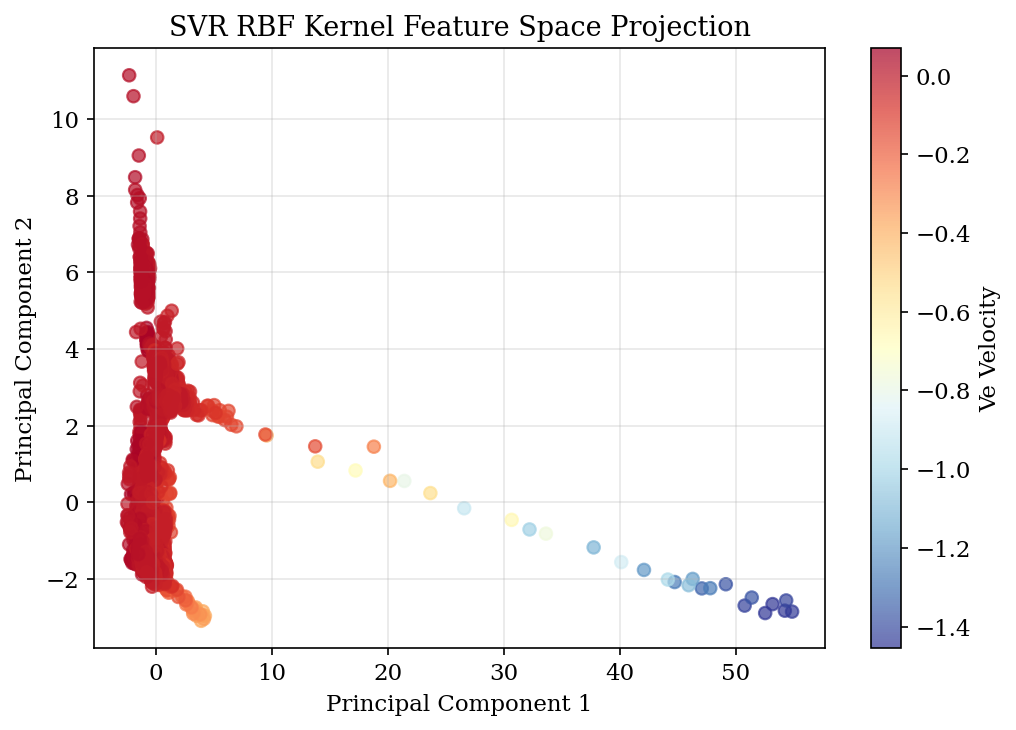

Saved: svr_kernel_projection.png


In [37]:
svr_models = {}
for comp in ['Ve', 'Vn']:
    svr = SVR(kernel='rbf', C=10.0, epsilon=0.001)
    svr.fit(X_train, y_train[comp])
    svr_models[comp] = svr

# ── Plot support vectors ──

from sklearn.decomposition import PCA

# Reduce feature space into 2D
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_train)

plt.figure(figsize=(7,5))

scatter = plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=y_train['Ve'],
    cmap='RdYlBu_r',
    alpha=0.7
)

plt.colorbar(scatter, label='Ve Velocity')

plt.title("SVR RBF Kernel Feature Space Projection")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.grid(True)

plt.tight_layout()

plt.savefig(
    "svr_kernel_projection.png",
    dpi=150,
    bbox_inches='tight'
)

plt.show()

print("Saved: svr_kernel_projection.png")

## BLOCK 8 — PHASE C: LSTM NEURAL NETWORK

LSTM sequences created. X_test_seq shape: (1381, 10, 20)
PHASE 5c — LSTM NEURAL NETWORK TRAINING
Epoch 1/100
139/139 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - loss: 0.0143 - mae: 0.0562 - val_loss: 7.0626e-04 - val_mae: 0.0215 - learning_rate: 0.0010
Epoch 2/100
139/139 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 0.0106 - mae: 0.0392 - val_loss: 4.3754e-04 - val_mae: 0.0164 - learning_rate: 0.0010
Epoch 3/100
139/139 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - loss: 0.0105 - mae: 0.0363 - val_loss: 3.5556e-04 - val_mae: 0.0145 - learning_rate: 0.0010
Epoch 4/100
139/139 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - loss: 0.0092 - mae: 0.0330 - val_loss: 5.8620e-04 - val_mae: 0.0185 - learning_rate: 0.0010
Epoch 5/100
139/139 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 0.0093 - mae: 0.0328 - val_loss: 4.2607e-04 - val_mae: 0.0155 - learning_rate: 0.0010
Epoch 6/100
139/139 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 0.0094 - mae: 0.0315 - val_loss: 5.0487e-04 - val_mae: 0.0165 - learning_rate: 0.0010
Epoch 7/100
139

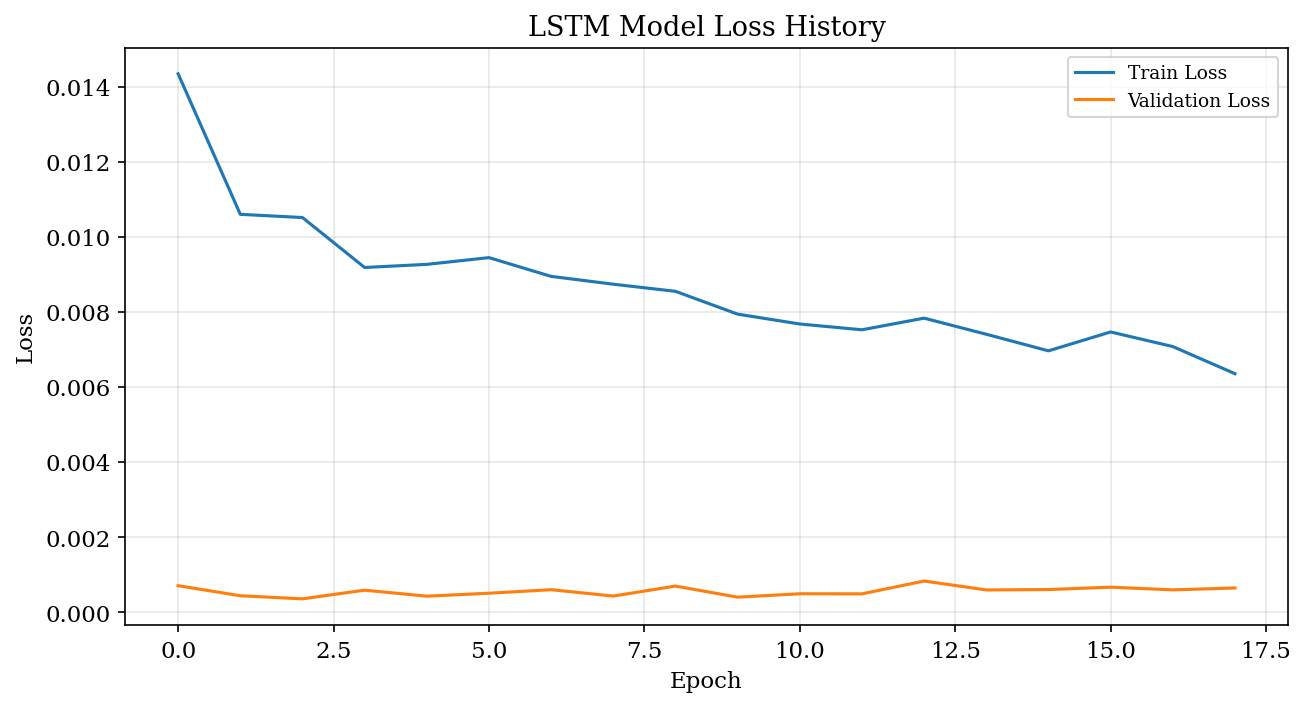

Saved: lstm_training_curves.png


In [38]:
SEQ_LEN = 10
def create_sequences(X, y, seq_len):
    X_seq = []; y_seq = []
    for i in range(len(X) - seq_len):
        X_seq.append(X[i:i+seq_len])
        y_seq.append(y.iloc[i+seq_len].values)
    return np.array(X_seq), np.array(y_seq)

# ── FIX: Use scaled y for sequences ──
X_train_seq, y_train_seq = create_sequences(X_train, y_train, SEQ_LEN)
X_test_seq,  y_test_seq  = create_sequences(X_test,  y_test,  SEQ_LEN)

print(f'LSTM sequences created. X_test_seq shape: {X_test_seq.shape}')

# ── FIX: Use tanh (standard for LSTM — relu causes dying neurons/underfitting) ──
lstm_model = Sequential([
    Input(shape=(SEQ_LEN, X_train_seq.shape[2])),
    LSTM(64, activation='tanh', recurrent_activation='sigmoid', return_sequences=True),
    Dropout(0.2),
    LSTM(32, activation='tanh', recurrent_activation='sigmoid'),
    Dropout(0.2),
    Dense(y_train_seq.shape[1])
])

lstm_model.compile(optimizer='adam', loss='mse', metrics=['mae'])

callbacks = [
    EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=7, min_lr=1e-6)
]

print("=" * 55)
print("PHASE 5c — LSTM NEURAL NETWORK TRAINING")
print("=" * 55)

history = lstm_model.fit(
    X_train_seq, y_train_seq,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    callbacks=callbacks,
    verbose=1
)

print("LSTM Model training complete.")

# Plot training history
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('LSTM Model Loss History')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()
plt.grid(True)
plt.savefig("lstm_training_curves.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: lstm_training_curves.png")

## BLOCK 9: REGRESSION EVALUATION

In [39]:
components = ['Ve', 'Vn']
predictions = {}

predictions['Random Forest'] = rf_model.predict(X_test)
predictions['SVR'] = np.column_stack([svr_models[c].predict(X_test) for c in components])
predictions['LSTM'] = lstm_model.predict(X_test_seq, verbose=0)

rows = []
for model_name, pred_arr in predictions.items():
    for i, comp in enumerate(components):
        if model_name == 'LSTM':
            actual = y_test[comp].iloc[SEQ_LEN:].values
        else:
            actual = y_test[comp].values
        pred = pred_arr[:len(actual), i]

        if len(actual) == len(pred):
            rows.append({
                'Model'    : model_name,
                'Component': comp,
                'RMSE'     : np.sqrt(mean_squared_error(actual, pred)),
                'MAE'      : mean_absolute_error(actual, pred),
                'R2'       : r2_score(actual, pred)
            })
        else:
            print(f"Warning: Length mismatch for {model_name} {comp}: actual({len(actual)}) vs pred({len(pred)})")

predictions_inv = predictions  # targets already in m/yr — no inverse transform needed
y_test_inv      = y_test

metrics_df = pd.DataFrame(rows)
metrics_df.to_csv("regression_metrics.csv", index=False)
display(metrics_df)
print("Saved: regression_metrics.csv")

,Model,Component,RMSE,MAE,R2
0,Random Forest,Ve,0.026739,0.007605,0.488278
1,Random Forest,Vn,0.010323,0.004301,0.854416
2,SVR,Ve,0.026801,0.005770,0.485888
3,SVR,Vn,0.008177,0.004163,0.908641
4,LSTM,Ve,0.033882,0.022163,0.182913
5,LSTM,Vn,0.031219,0.023609,-0.329249


Saved: regression_metrics.csv


## BLOCK 10: PLOTS ACTUAL VS ESTIMATED

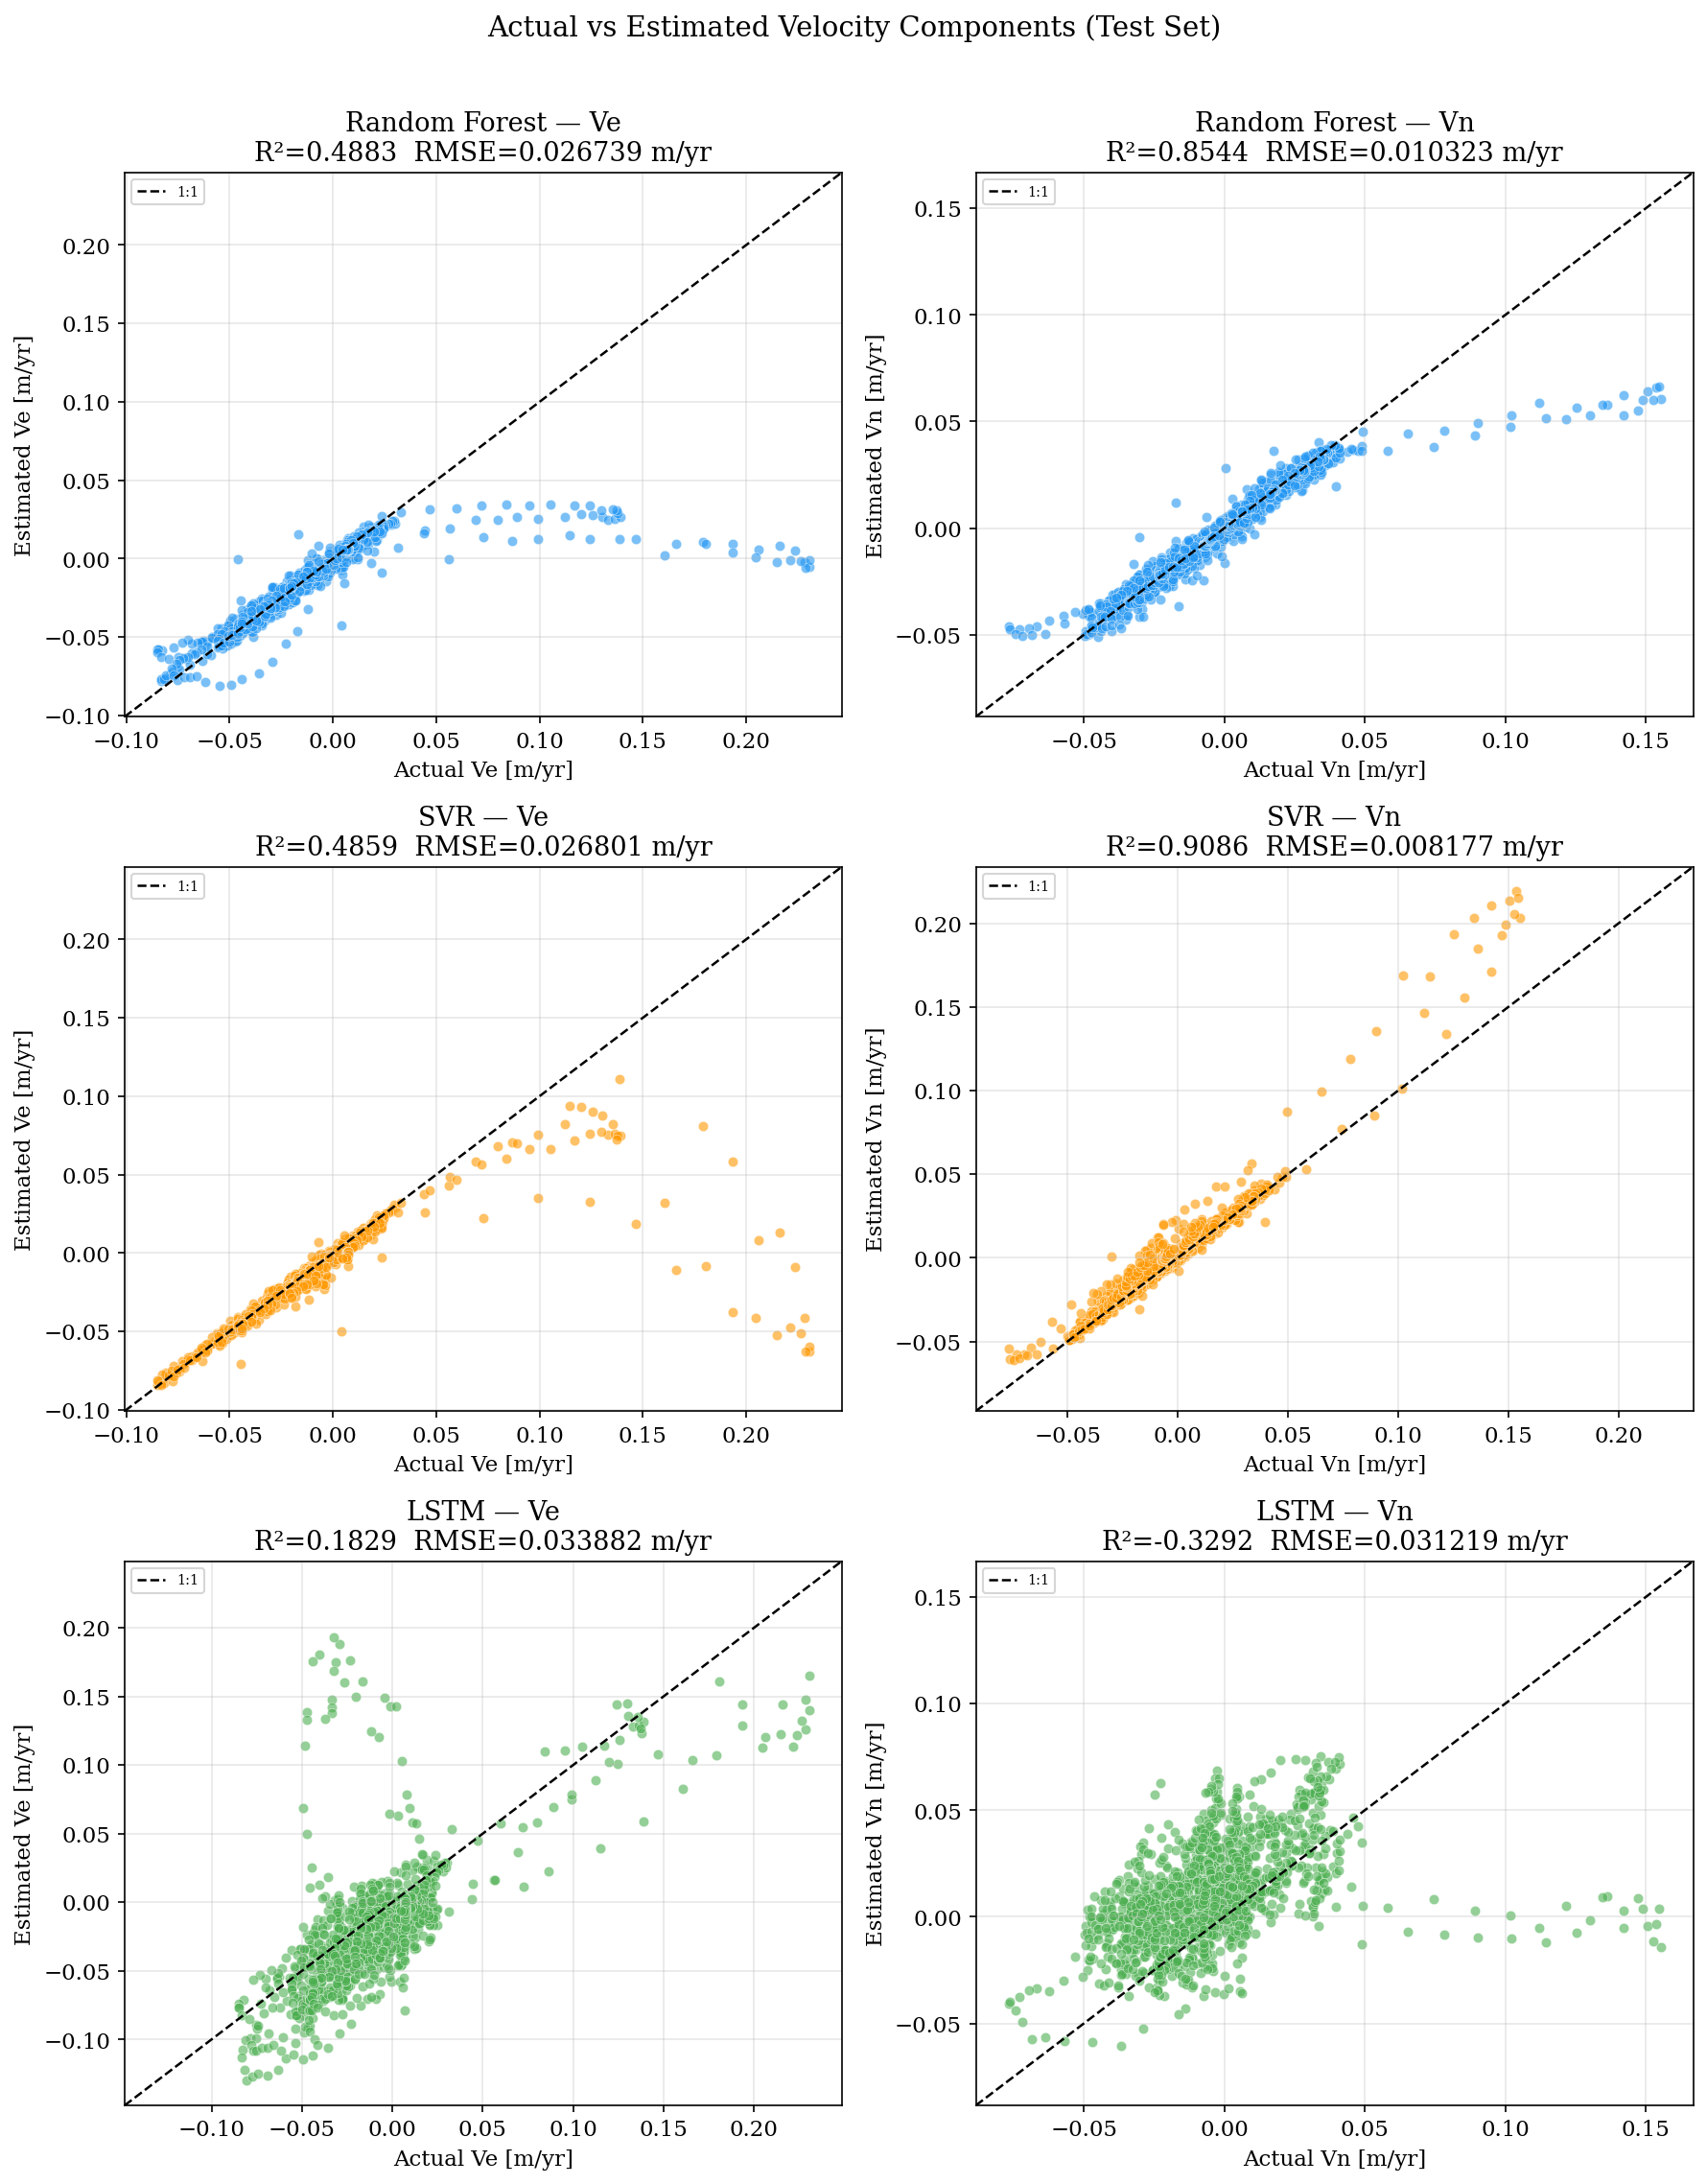

Saved: actual_vs_estimated.png


In [40]:
model_names = list(predictions.keys())
n_models    = len(model_names)

fig, axes = plt.subplots(n_models, 2, figsize=(12, 5 * n_models))

for row_i, model_name in enumerate(model_names):
    pred_arr = predictions_inv[model_name]
    color    = MODEL_COLORS[model_name]

    for col_i, comp in enumerate(components):
        ax = axes[row_i][col_i]
        if model_name == 'LSTM':
            actual = y_test_inv[comp].iloc[SEQ_LEN:].values
        else:
            actual = y_test_inv[comp].values
        pred = pred_arr[:len(actual), col_i]

        mrow = metrics_df[(metrics_df['Model'] == model_name) &
                          (metrics_df['Component'] == comp)]
        r2   = mrow['R2'].values[0]
        rmse = mrow['RMSE'].values[0]

        ax.scatter(actual, pred, alpha=0.6, s=25, color=color,
                   edgecolors='white', lw=0.3)
        lo     = min(actual.min(), pred.min())
        hi     = max(actual.max(), pred.max())
        margin = (hi - lo) * 0.05
        ax.plot([lo - margin, hi + margin],
                [lo - margin, hi + margin], 'k--', lw=1.2, label='1:1')
        ax.set_xlim(lo - margin, hi + margin)
        ax.set_ylim(lo - margin, hi + margin)
        ax.set_xlabel(f"Actual {comp} [m/yr]")
        ax.set_ylabel(f"Estimated {comp} [m/yr]")
        ax.set_title(f"{model_name} — {comp}\nR²={r2:.4f}  RMSE={rmse:.6f} m/yr")
        ax.legend(fontsize=7)

fig.suptitle("Actual vs Estimated Velocity Components (Test Set)",
             fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("actual_vs_estimated.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: actual_vs_estimated.png")

## BLOCK 11: RESIDUAL DISTRIBUTIONS

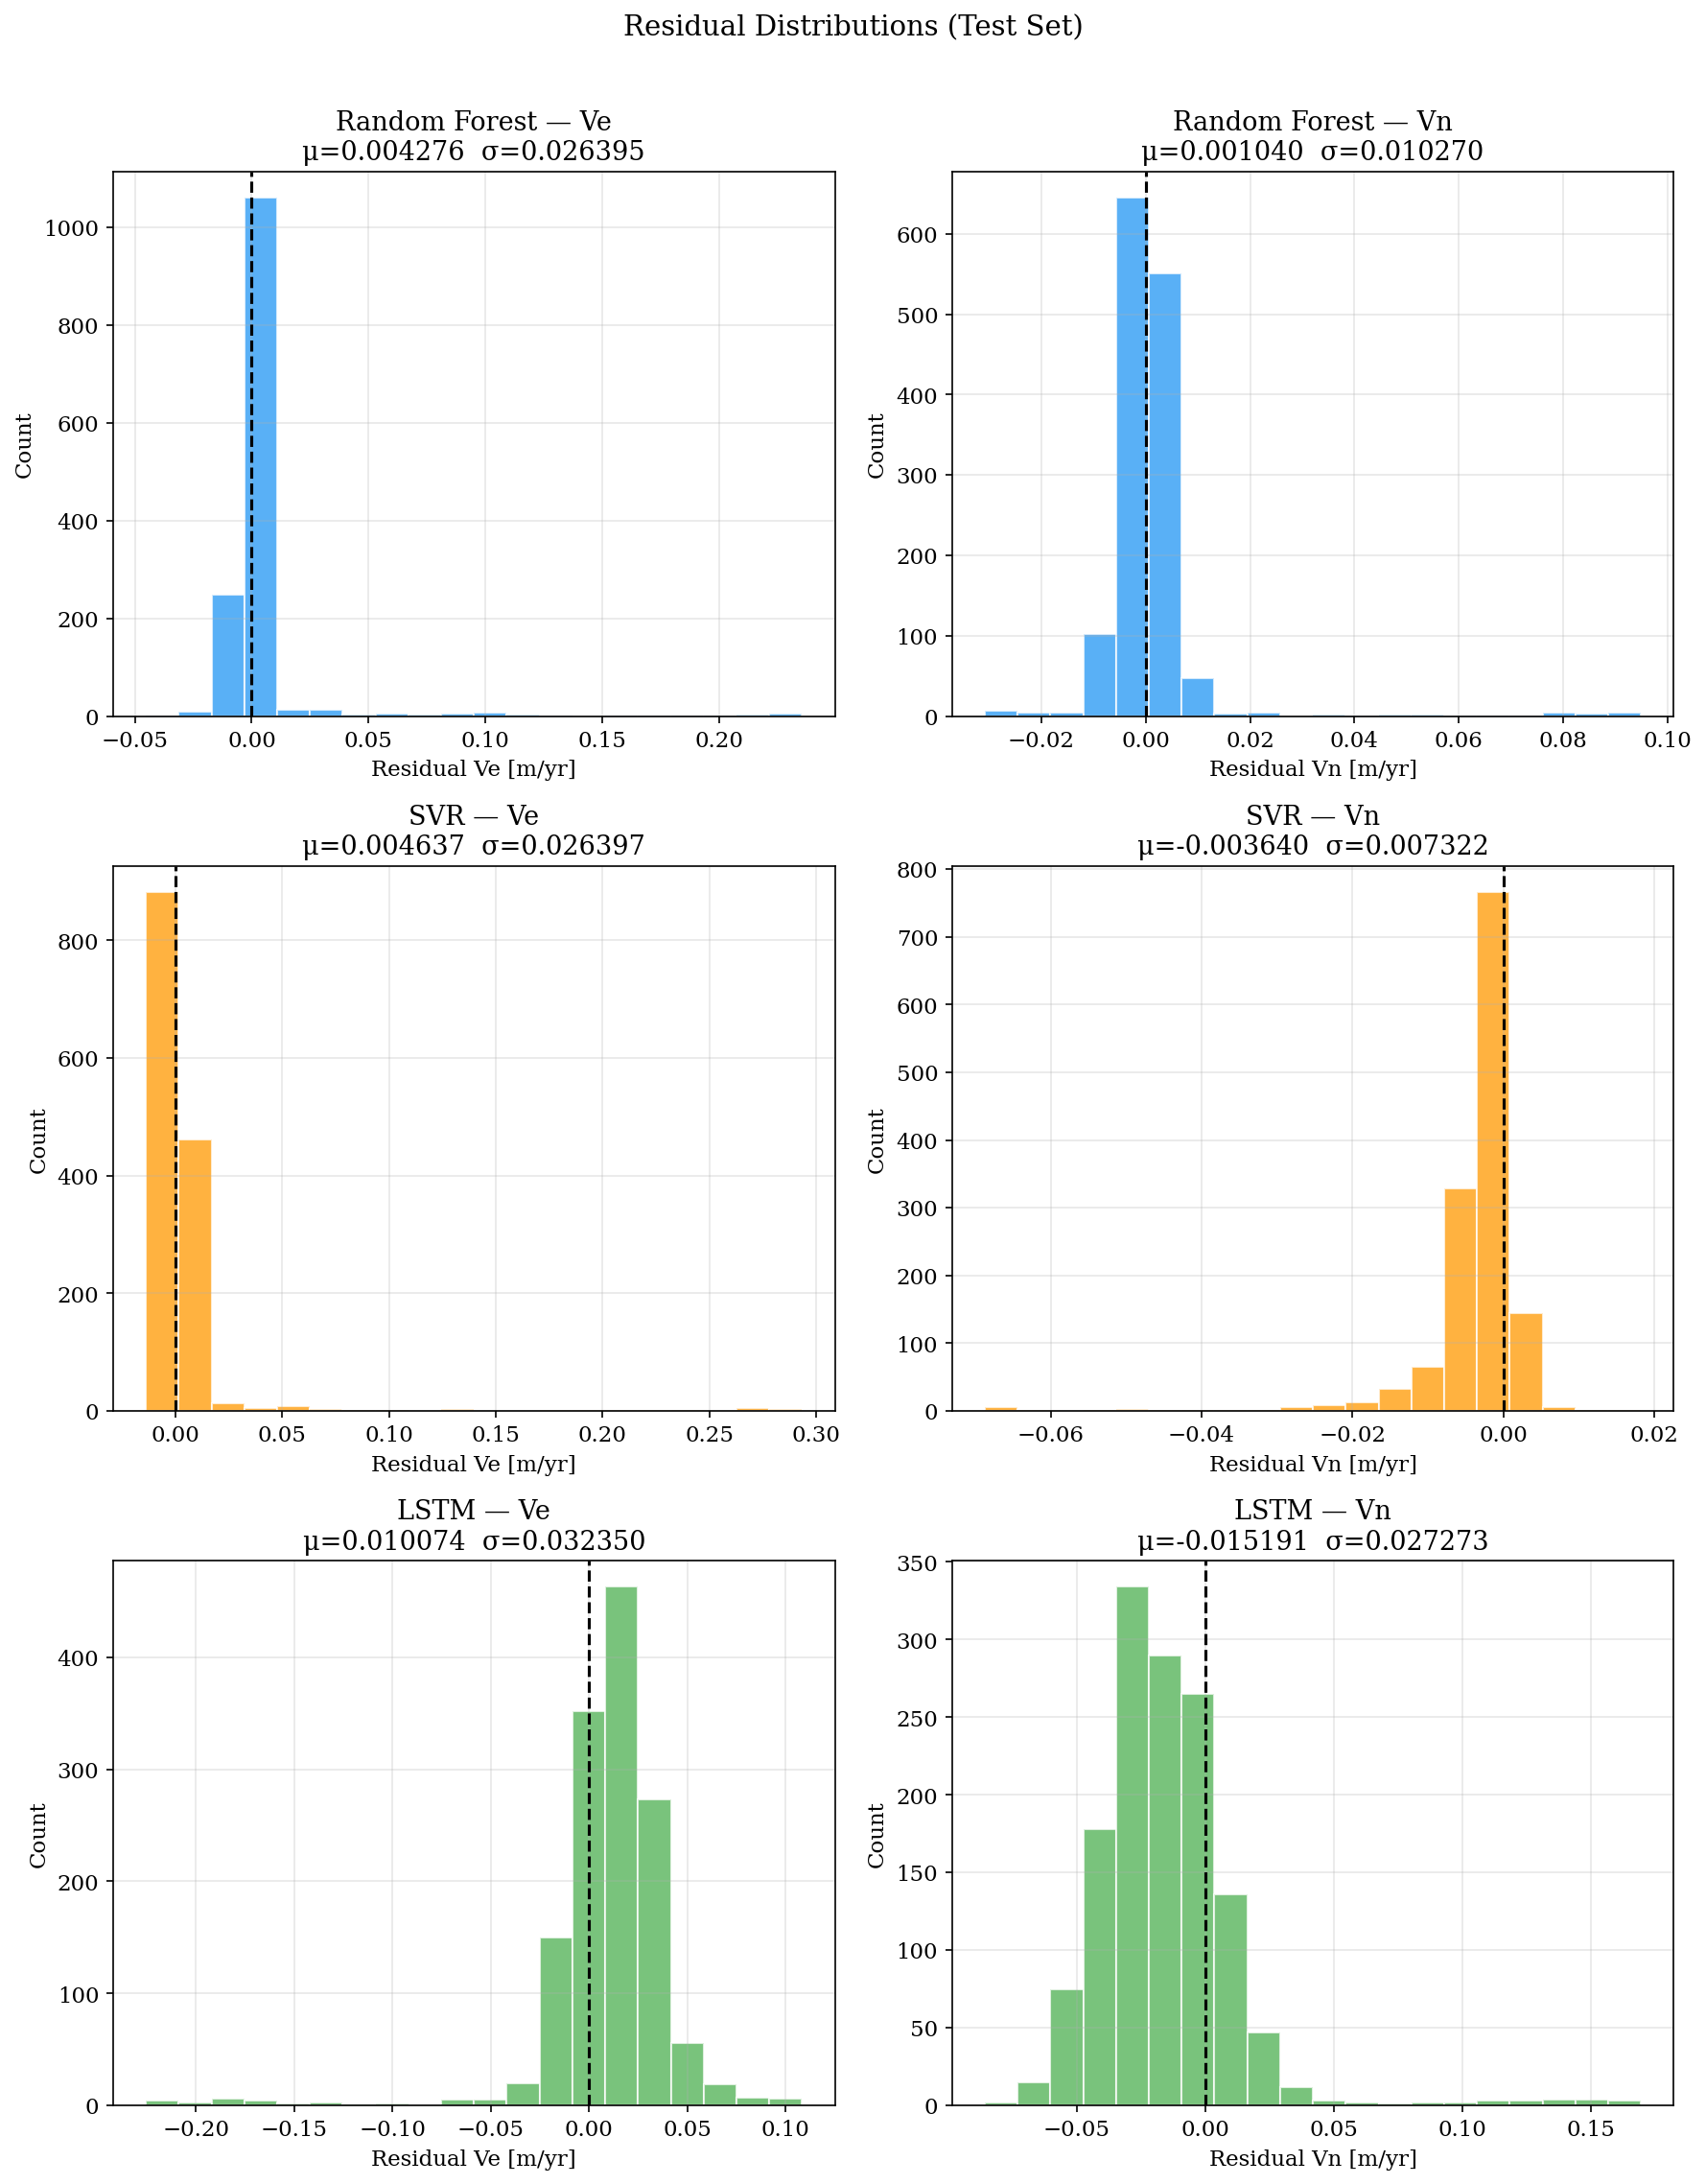

Saved: residual_distributions.png


In [41]:
fig, axes = plt.subplots(n_models, 2, figsize=(12, 5 * n_models))

for row_i, model_name in enumerate(model_names):
    pred_arr = predictions_inv[model_name]
    color    = MODEL_COLORS[model_name]

    for col_i, comp in enumerate(components):
        ax = axes[row_i][col_i]
        if model_name == 'LSTM':
            actual_y = y_test_inv[comp].iloc[SEQ_LEN:].values
        else:
            actual_y = y_test_inv[comp].values

        residual = actual_y - pred_arr[:len(actual_y), col_i]

        ax.hist(residual, bins=20, color=color, alpha=0.75, edgecolor='white')
        ax.axvline(0, color='black', lw=1.5, ls='--')
        ax.set_xlabel(f"Residual {comp} [m/yr]")
        ax.set_ylabel("Count")
        ax.set_title(f"{model_name} — {comp}\n"
                     f"μ={residual.mean():.6f}  σ={residual.std():.6f}")

fig.suptitle("Residual Distributions (Test Set)", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("residual_distributions.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: residual_distributions.png")

## BLOCK 12: MODEL COMPARISON BAR CHART

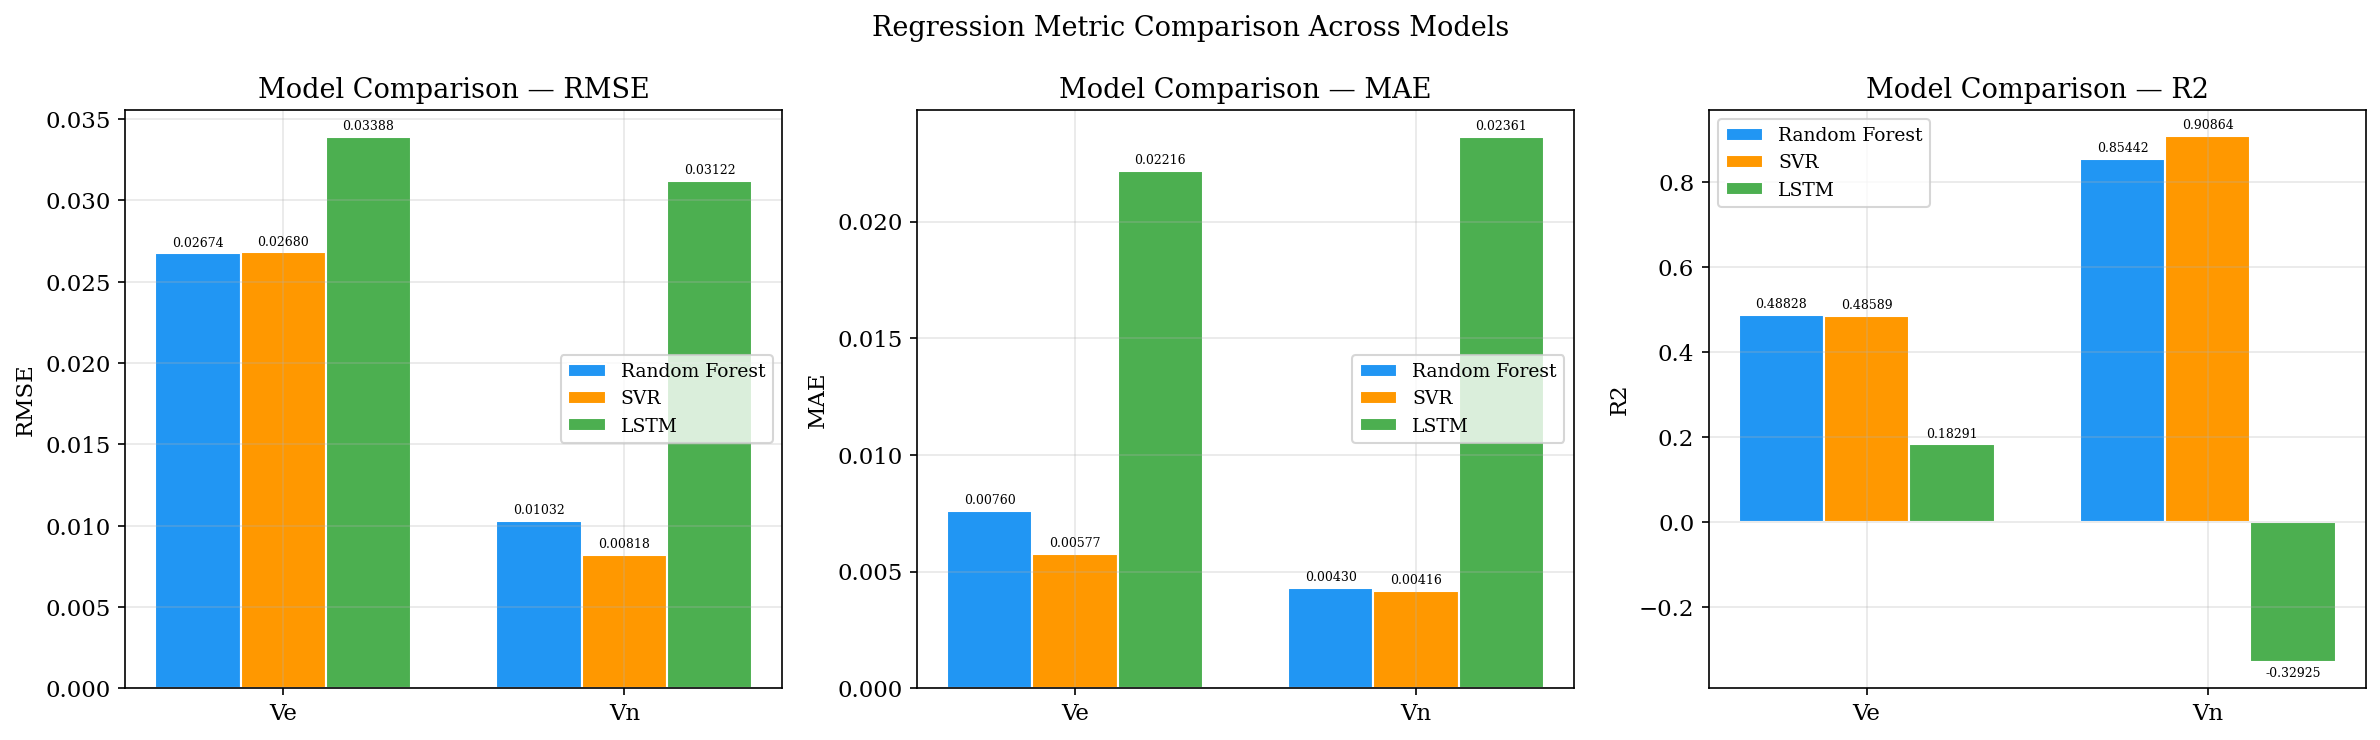

Saved: model_comparison.png


In [42]:
metric_keys = ['RMSE', 'MAE', 'R2']
fig, axes   = plt.subplots(1, 3, figsize=(16, 5))

for ax, metric in zip(axes, metric_keys):
    x     = np.arange(len(components))
    width = 0.25

    for i, model_name in enumerate(model_names):
        sub    = metrics_df[metrics_df['Model'] == model_name]
        values = [sub[sub['Component'] == c][metric].values[0]
                  for c in components]
        bars = ax.bar(x + i * width, values, width,
                      label=model_name,
                      color=MODEL_COLORS[model_name],
                      edgecolor='white')
        ax.bar_label(bars, fmt='%.5f', fontsize=6, padding=2)

    ax.set_xticks(x + width)
    ax.set_xticklabels(components)
    ax.set_title(f"Model Comparison — {metric}")
    ax.set_ylabel(metric)
    ax.legend()

plt.suptitle("Regression Metric Comparison Across Models", fontsize=13)
plt.tight_layout()
plt.savefig("model_comparison.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: model_comparison.png")

## BLOCK 13: SELECT BEST MODEL & RE-ESTIMATE ALL STATIONS

In [43]:
best_model_name = metrics_df.groupby('Model')['R2'].mean().idxmax()
print(f'Best model for final estimation: {best_model_name}')

# Use all 27 feature columns to match the trained LSTM input shape
Xs_all = scaler.transform(vel_df[feature_cols])
full_Ve_est = np.full(len(vel_df), np.nan)
full_Vn_est = np.full(len(vel_df), np.nan)

if best_model_name == 'LSTM':
    Xs_all_seq, _ = create_sequences(Xs_all, pd.DataFrame(np.zeros((len(Xs_all), 2))), SEQ_LEN)
    preds = lstm_model.predict(Xs_all_seq, verbose=0)
    full_Ve_est[SEQ_LEN:] = preds[:, 0]
    full_Vn_est[SEQ_LEN:] = preds[:, 1]
elif best_model_name == 'SVR':
    full_Ve_est = svr_models['Ve'].predict(Xs_all)
    full_Vn_est = svr_models['Vn'].predict(Xs_all)
else:
    preds_rf = rf_model.predict(X_test)
    # Logic to handle RF mapping if necessary, otherwise use full data
    full_Ve_est = rf_model.predict(Xs_all)[:, 0]
    full_Vn_est = rf_model.predict(Xs_all)[:, 1]

vel_df['Ve_est'] = full_Ve_est
vel_df['Vn_est'] = full_Vn_est
display(vel_df[['site', 'latitude', 'longitude', 'Ve', 'Vn', 'Ve_est', 'Vn_est']].head())
print(f'Re-estimation complete. NaN counts: {vel_df["Ve_est"].isna().sum()}')

Best model for final estimation: SVR


,site,latitude,longitude,Ve,Vn,Ve_est,Vn_est
0,PSUR,9.791809,125.493698,-0.013538,0.025486,-0.014071,0.025924
1,PSUR,9.791809,125.493698,-0.013953,0.025456,-0.013672,0.026096
2,PGEN,6.064912,125.131662,-0.013445,-0.008088,-0.013588,-0.005923
3,PGEN,6.064912,125.131662,-0.013404,-0.008279,-0.013495,-0.008371
4,PSUR,9.791809,125.493698,-0.014551,0.025427,-0.014833,0.025717


Re-estimation complete. NaN counts: 0


## BLOCK 14: SITE SUMMARY AND DATA GAPS

In [44]:
from sklearn.linear_model import LinearRegression

print("=" * 55)
print("RECALCULATING MISSING VELOCITIES")
print("=" * 55)

# --- FIX: Ensure site_summary is a DataFrame --- FIX
# Check if site_summary is NOT a pandas DataFrame or if it doesn't contain the 'site' column.
# If not, initialize it from vel_df. This handles cases where site_summary might be a list from a previous run
# or was not properly initialized as a DataFrame.
if not (isinstance(site_summary, pd.DataFrame) and 'site' in site_summary.columns):
    print("Initializing or re-initializing site_summary DataFrame from vel_df.")
    # Calculate mean estimated velocities and other summary stats for each site
    site_summary = vel_df.groupby('site').agg(
        first_latitude=('latitude', 'first'),
        first_longitude=('longitude', 'first'),
        start_year=('decimal_year', 'min'),
        end_year=('decimal_year', 'max'),
        mean_Ve_est=('Ve_est', 'mean'),
        mean_Vn_est=('Vn_est', 'mean')
    ).reset_index()

    site_summary['observation_duration_years'] = site_summary['end_year'] - site_summary['start_year']

    # Calculate the horizontal velocity magnitude from the mean estimated components
    site_summary['horizontal_velocity_magnitude_m_yr'] = np.sqrt(
        site_summary['mean_Ve_est']**2 + site_summary['mean_Vn_est']**2
    )
    print("Initialized site_summary DataFrame from vel_df.")

# --------------------------------------------------------------------------
# NEW FIX: Identify and calculate velocities for sites completely missing from vel_df
# These are sites that were likely filtered out due to insufficient epochs earlier.
# --------------------------------------------------------------------------

# Get all unique sites from the initially combined dataframe (before epoch filtering)
all_sites_original_raw = combined_df['site'].unique()

# Get sites that made it into vel_df and thus site_summary
sites_in_vel_df = site_summary['site'].unique()

# Identify sites that are in the original data but NOT in site_summary
truly_missing_sites_for_vel_calc = list(set(all_sites_original_raw) - set(sites_in_vel_df))

if truly_missing_sites_for_vel_calc:
    print(f"Identifying and calculating velocities for {len(truly_missing_sites_for_vel_calc)} sites that were previously excluded from vel_df: {', '.join(truly_missing_sites_for_vel_calc)}")
    newly_calculated_site_data = []

    for site_id in truly_missing_sites_for_vel_calc:
        site_raw_data = combined_df[combined_df['site'] == site_id].copy()

        # --- Re-apply column cleaning logic from BLOCK 4 for this subset ---
        site_raw_data.columns = site_raw_data.columns.str.strip().str.lower()
        new_cols_local = []
        for col in site_raw_data.columns:
            col = col.replace('__', '')
            col = col.replace('(m)', '')
            col = col.replace('(deg)', '')
            col = col.replace('.', '')
            col = col.strip('_')
            new_cols_local.append(col)
        site_raw_data.columns = new_cols_local

        # Apply specific transformations as in BLOCK 4
        if 'longitude' in site_raw_data.columns:
            site_raw_data['longitude'] = site_raw_data['longitude'] % 360
        if 'height' in site_raw_data.columns:
            site_raw_data['height'] = pd.to_numeric(site_raw_data['height'], errors='coerce')

        if 'yyyyyyyy' in site_raw_data.columns:
            site_raw_data = site_raw_data.rename(columns={'yyyyyyyy': 'decimal_year'})
        elif 'yymmmdd' in site_raw_data.columns:
            site_raw_data = site_raw_data.rename(columns={'yymmmdd': 'decimal_year'})

        # Select only the critical columns needed for velocity calculation and drop NaNs
        needed_cols = ['site', 'decimal_year', 'east', 'north', 'latitude', 'longitude']
        site_data_cleaned = site_raw_data[[c for c in needed_cols if c in site_raw_data.columns]].copy()
        site_data_cleaned = site_data_cleaned.dropna(subset=['decimal_year', 'east', 'north', 'latitude', 'longitude'])

        if len(site_data_cleaned) < 2: # Need at least 2 points for linear regression
            print(f"  Skipping {site_id}: Not enough valid data points ({len(site_data_cleaned)}) for velocity calculation after cleaning.")
            continue

        # Perform Linear Regression for Ve and Vn
        X_time = site_data_cleaned['decimal_year'].values.reshape(-1, 1)
        y_east = site_data_cleaned['east'].values
        y_north = site_data_cleaned['north'].values

        ve_model = LinearRegression().fit(X_time, y_east)
        vn_model = LinearRegression().fit(X_time, y_north)

        estimated_Ve = ve_model.coef_[0]
        estimated_Vn = vn_model.coef_[0]
        estimated_Vmag = np.sqrt(estimated_Ve**2 + estimated_Vn**2)

        # Collect summary data for this site
        newly_calculated_site_data.append({
            'site': site_id,
            'first_latitude': site_data_cleaned['latitude'].iloc[0],
            'first_longitude': site_data_cleaned['longitude'].iloc[0],
            'start_year': site_data_cleaned['decimal_year'].min(),
            'end_year': site_data_cleaned['decimal_year'].max(),
            'mean_Ve_est': estimated_Ve,
            'mean_Vn_est': estimated_Vn,
            'observation_duration_years': site_data_cleaned['decimal_year'].max() - site_data_cleaned['decimal_year'].min(),
            'horizontal_velocity_magnitude_m_yr': estimated_Vmag
        })

    if newly_calculated_site_data:
        new_site_summary_part = pd.DataFrame(newly_calculated_site_data)
        site_summary = pd.concat([site_summary, new_site_summary_part], ignore_index=True)
        print(f"Added velocities for {len(newly_calculated_site_data)} previously excluded sites to site_summary.")
    else:
        print("No new velocities calculated for previously excluded sites.")

# Identify sites with NaN in horizontal_velocity_magnitude_m_yr (these are sites IN site_summary but with NaN velocity estimates)
sites_with_nan_vel = site_summary[site_summary['horizontal_velocity_magnitude_m_yr'].isna()]['site'].tolist()

if not sites_with_nan_vel:
    print("No sites found with missing horizontal velocities to recalculate within the existing vel_df derived summary.")
else:
    print(f"Recalculating velocities for {len(sites_with_nan_vel)} sites already in vel_df but with NaN estimates: {', '.join(sites_with_nan_vel)}")
    new_velocities = []

    # Iterate through each site identified
    for site_id in sites_with_nan_vel:
        # Get raw data for the current site from df (which has all cleaned original data that passed MIN_EPOCHS)
        site_data = df[df['site'] == site_id].copy()

        if len(site_data) < 2:
            print(f"  Skipping {site_id}: Not enough data points ({len(site_data)}) for linear regression.")
            continue

        # Prepare data for linear regression
        X_time = site_data['decimal_year'].values.reshape(-1, 1)
        # Corrected: Use 'east' and 'north' displacement components (in meters) for regression
        y_east = site_data['east'].values
        y_north = site_data['north'].values

        # Fit linear regression models
        ve_model = LinearRegression()
        vn_model = LinearRegression()

        # Ensure enough samples for regression
        if len(X_time) >= 2:
            ve_model.fit(X_time, y_east)
            vn_model.fit(X_time, y_north)
            estimated_Ve = ve_model.coef_[0]
            estimated_Vn = vn_model.coef_[0]
            estimated_Vmag = np.sqrt(estimated_Ve**2 + estimated_Vn**2)

            new_velocities.append({
                'site': site_id,
                'horizontal_velocity_magnitude_m_yr': estimated_Vmag,
                'mean_Ve_est': estimated_Ve,
                'mean_Vn_est': estimated_Vn
            })
            print(f"  Site {site_id}: Estimated velocity magnitude = {estimated_Vmag:.4f} m/yr")
        else:
            print(f"  Skipping {site_id}: Insufficient data for linear regression ({len(X_time)} epochs).")

    # Update site_summary with the new velocities
    if new_velocities:
        new_vel_df_for_update = pd.DataFrame(new_velocities)
        # Use update to modify existing rows or fill NaNs
        site_summary = site_summary.set_index('site')
        new_vel_df_for_update = new_vel_df_for_update.set_index('site')
        site_summary.update(new_vel_df_for_update)
        site_summary = site_summary.reset_index()

# Display the updated site summary
site_summary_display = site_summary[[
    'site', 'first_latitude', 'first_longitude',
    'start_year', 'end_year', 'observation_duration_years',
    'horizontal_velocity_magnitude_m_yr'
]]
display(site_summary_display.round(4))

site_summary_display.to_csv("site_data_summary.csv", index=False)
print("Updated: site_data_summary.csv")

RECALCULATING MISSING VELOCITIES
Initializing or re-initializing site_summary DataFrame from vel_df.
Initialized site_summary DataFrame from vel_df.
Identifying and calculating velocities for 3 sites that were previously excluded from vel_df: PTCG, PMRM, PMAI
Added velocities for 3 previously excluded sites to site_summary.
No sites found with missing horizontal velocities to recalculate within the existing vel_df derived summary.


,site,first_latitude,first_longitude,start_year,end_year,observation_duration_years,horizontal_velocity_magnitude_m_yr
0,DVAO,7.0719,125.6129,2016.1232,2024.7091,8.5859,0.0306
1,PBIS,8.1892,126.3539,2017.7194,2024.7036,6.9842,0.0369
2,PCOT,7.1996,124.2470,2017.1882,2024.7036,7.5154,0.0217
3,PDAV,7.1265,125.6434,2015.0910,2021.7112,6.6202,0.0340
4,PDDN,7.4594,125.7833,2021.7112,2023.7070,1.9958,0.0290
5,PDIP,8.5868,123.3443,2015.8193,2022.7105,6.8912,0.0078
6,PGEN,6.0649,125.1317,2014.3573,2026.1246,11.7673,0.0137
7,PSUR,9.7918,125.4937,2014.3546,2019.7207,5.3661,0.1156
8,PTGO,8.5259,124.7550,2015.0910,2022.7105,7.6195,0.0183
9,PZAM,6.9286,122.0650,2015.1485,2022.7105,7.5620,0.0136


Updated: site_data_summary.csv


## BLOCK 15: TIME SERIES GRAPH

PER-SITE EAST/NORTH TIME SERIES PLOTS
Plotting time series for 10 sites: ['DVAO', 'PBIS', 'PCOT', 'PDAV', 'PDDN', 'PDIP', 'PGEN', 'PSUR', 'PTGO', 'PZAM']


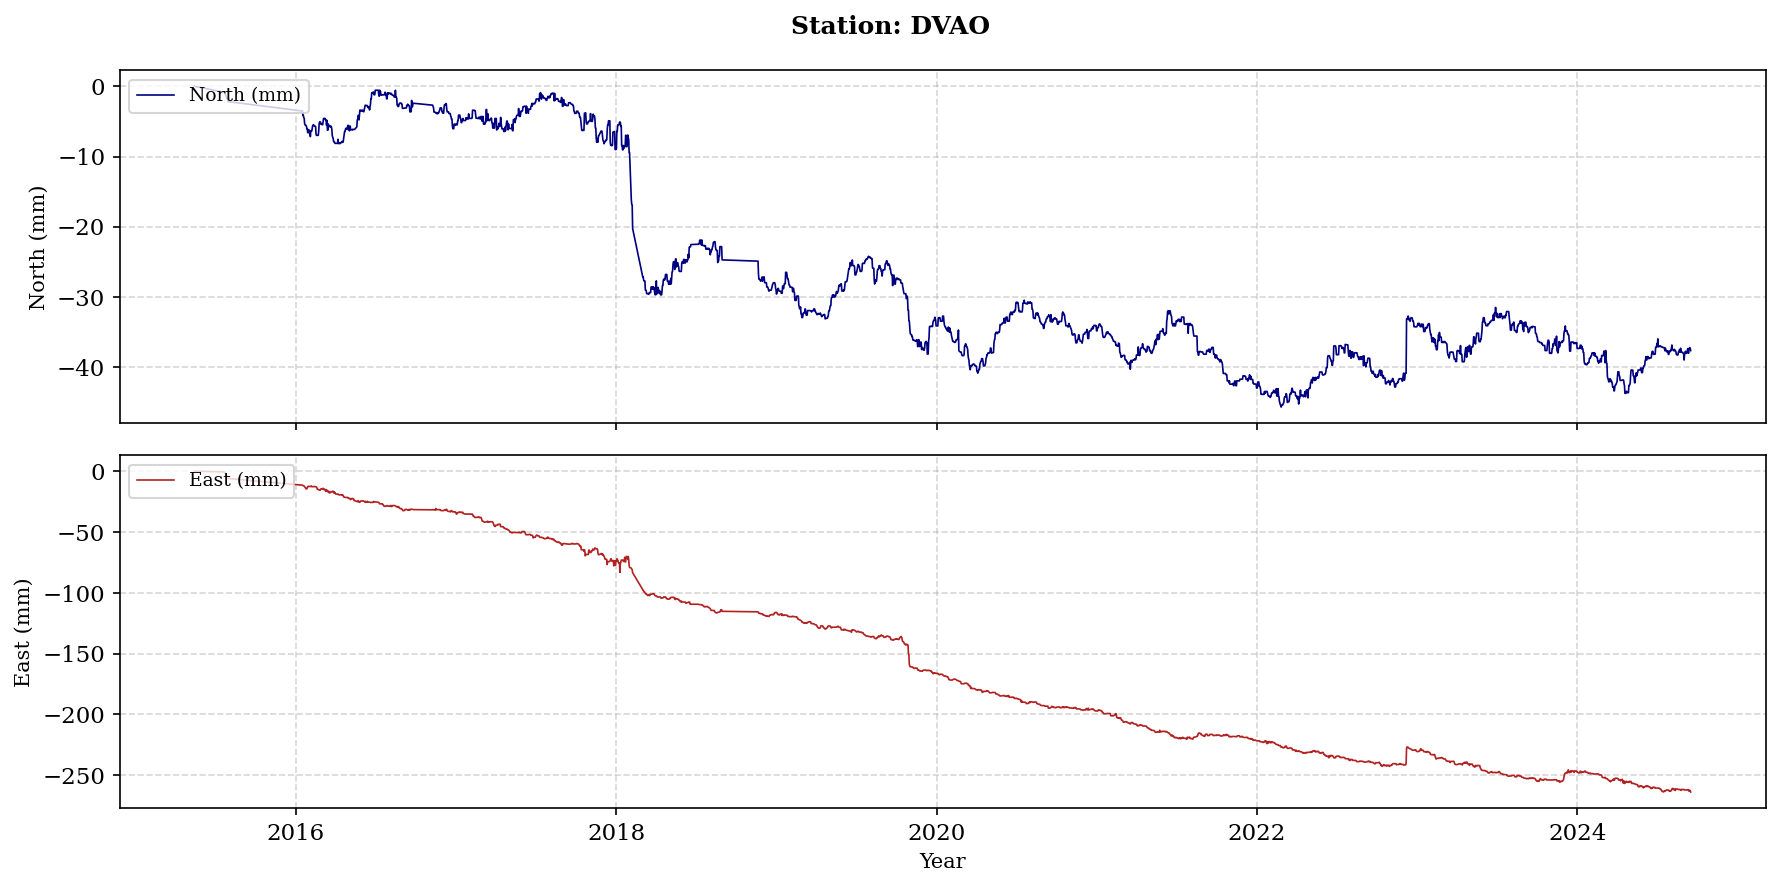

  ✓ DVAO  |  2980 epochs


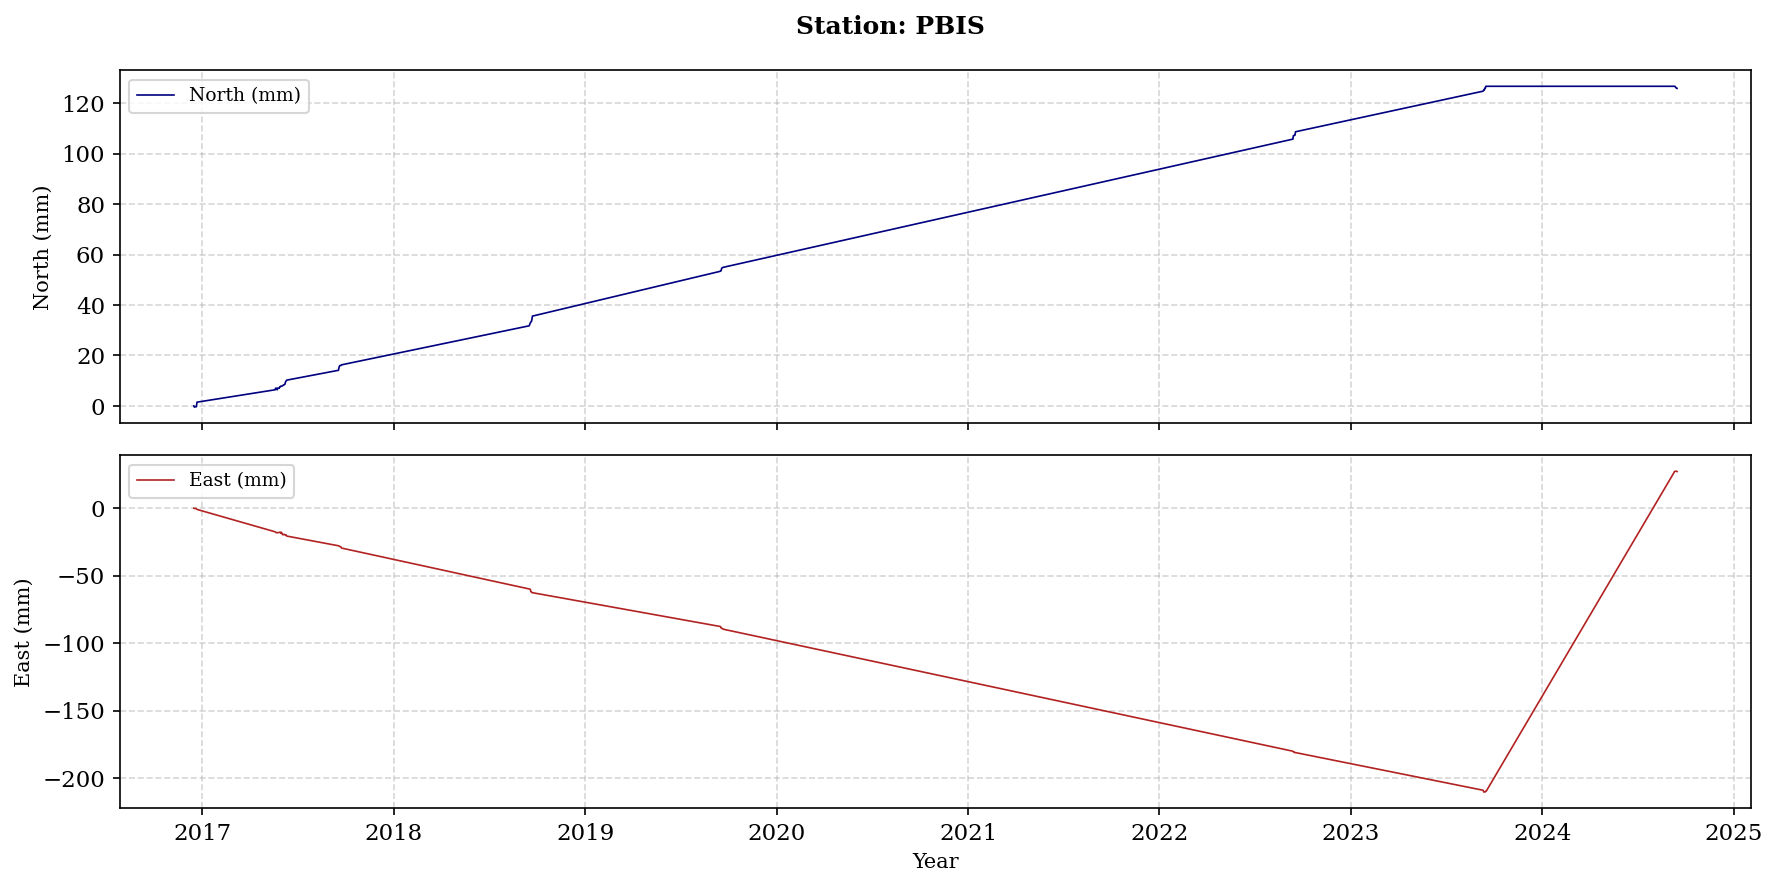

  ✓ PBIS  |  71 epochs


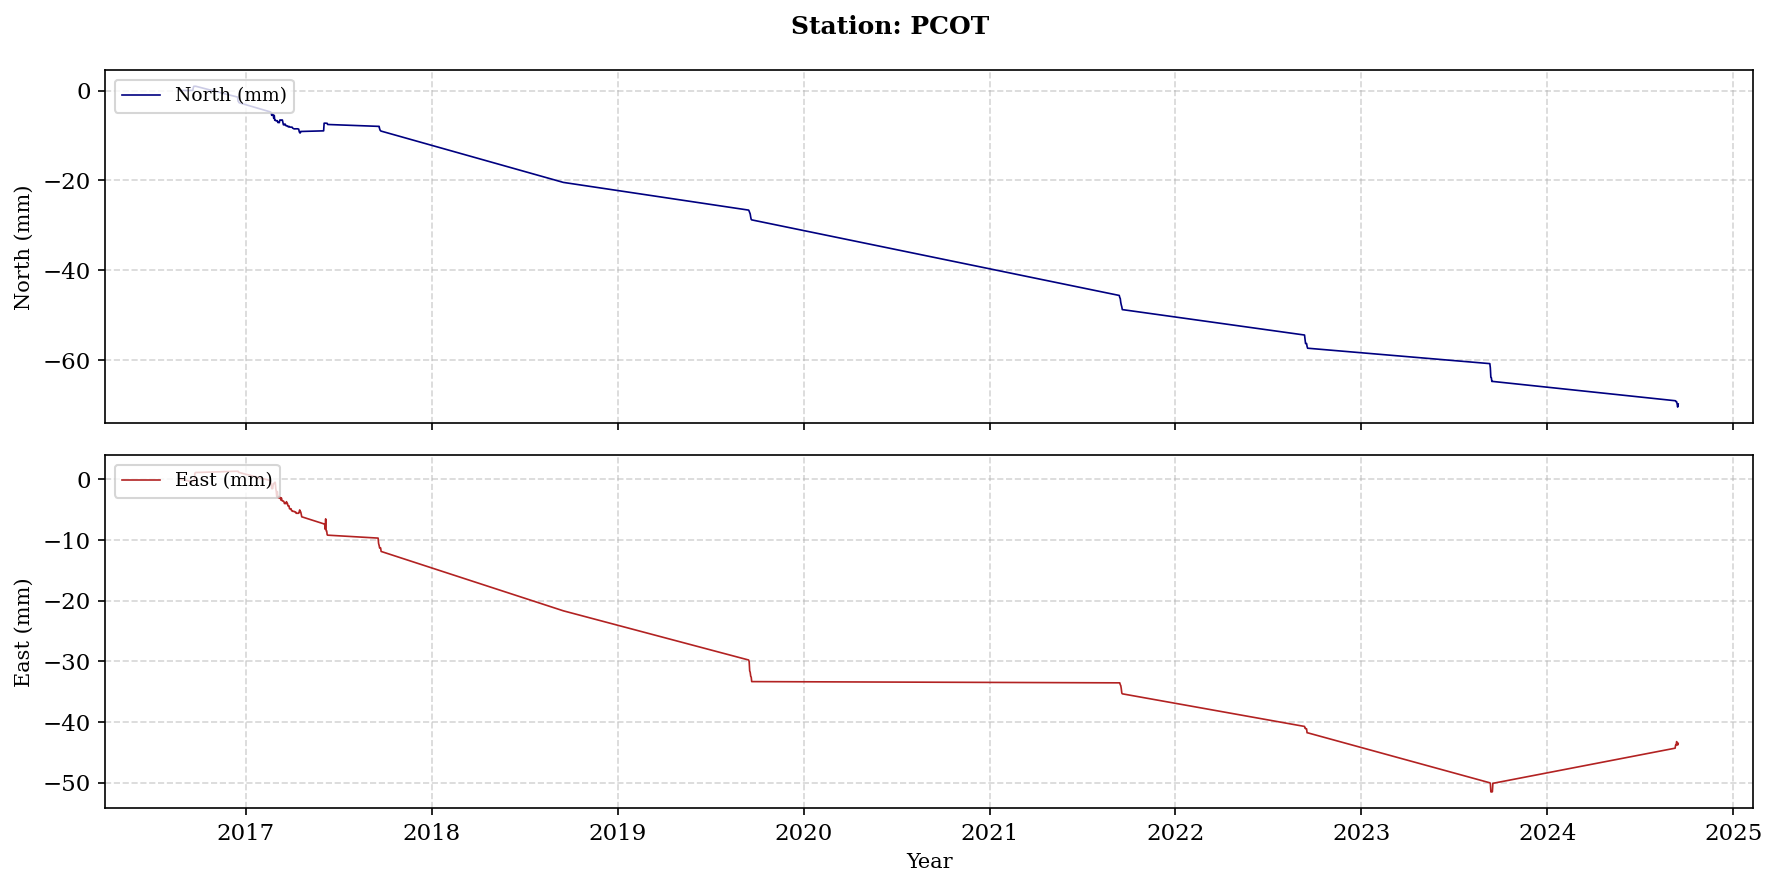

  ✓ PCOT  |  125 epochs


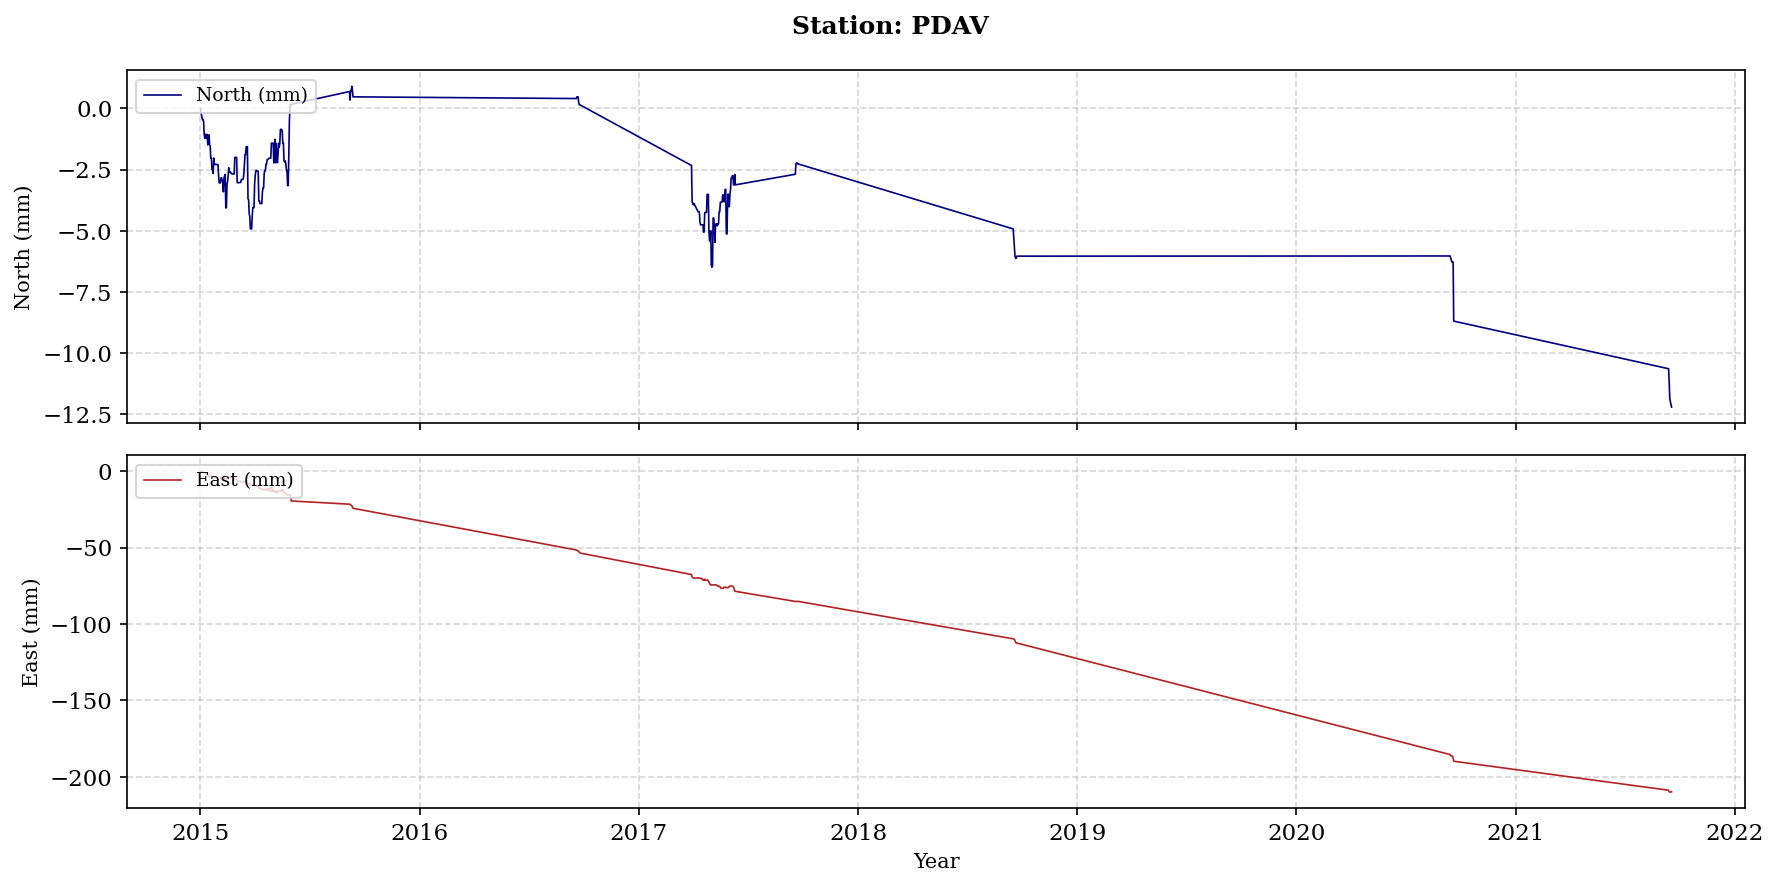

  ✓ PDAV  |  257 epochs


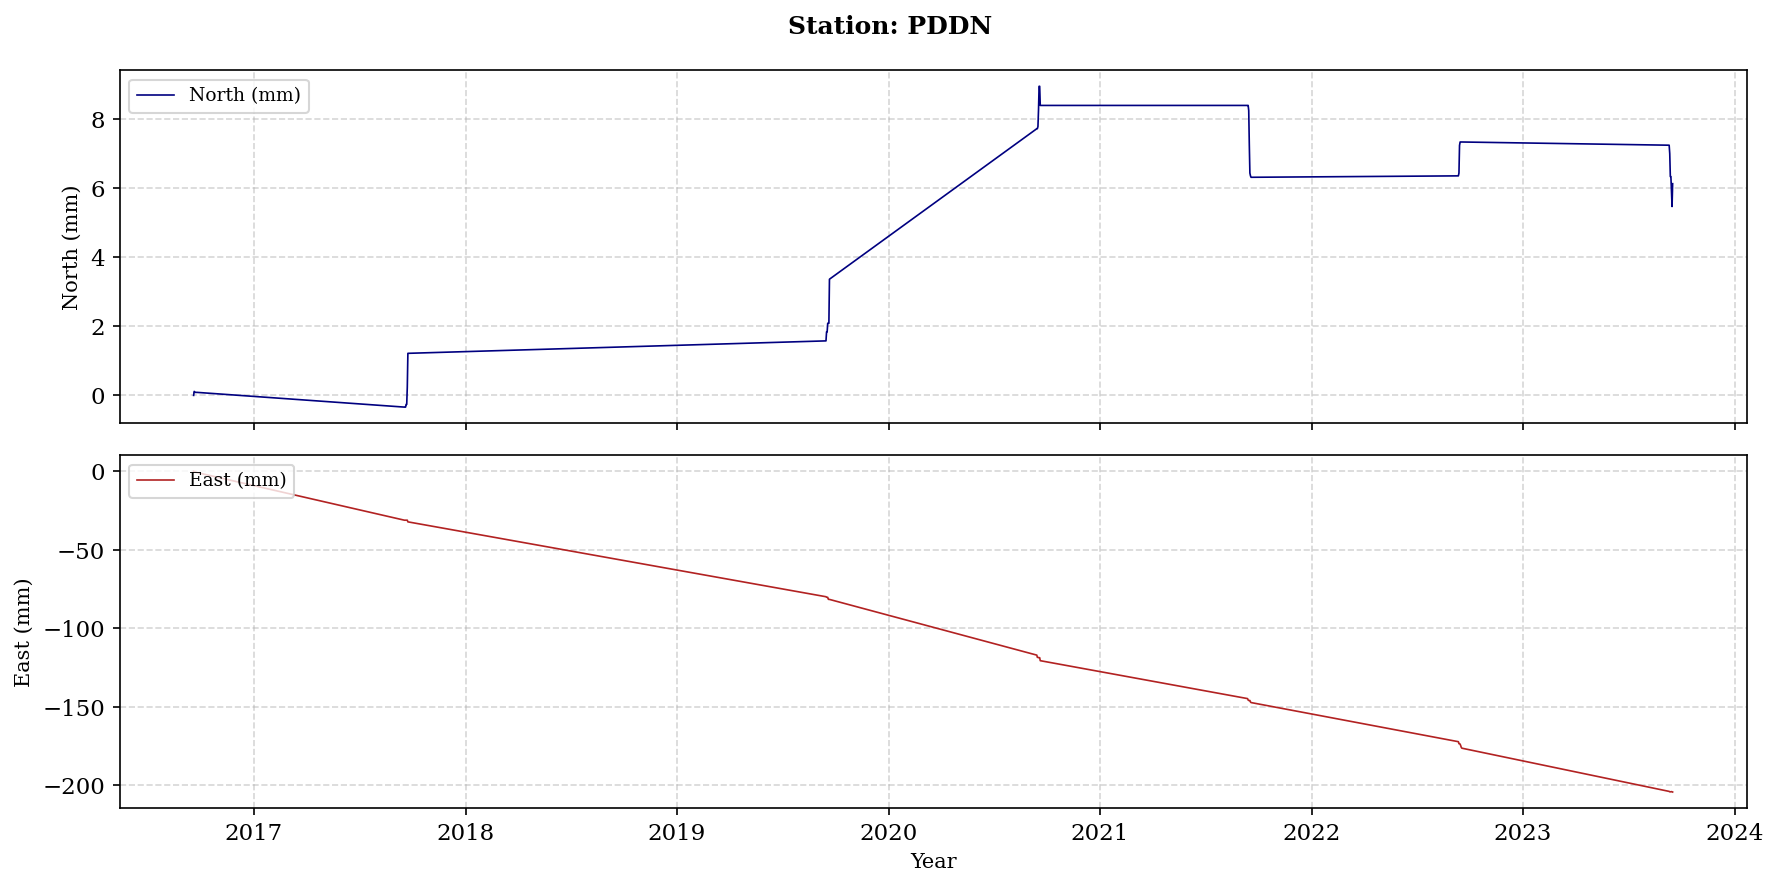

  ✓ PDDN  |  49 epochs


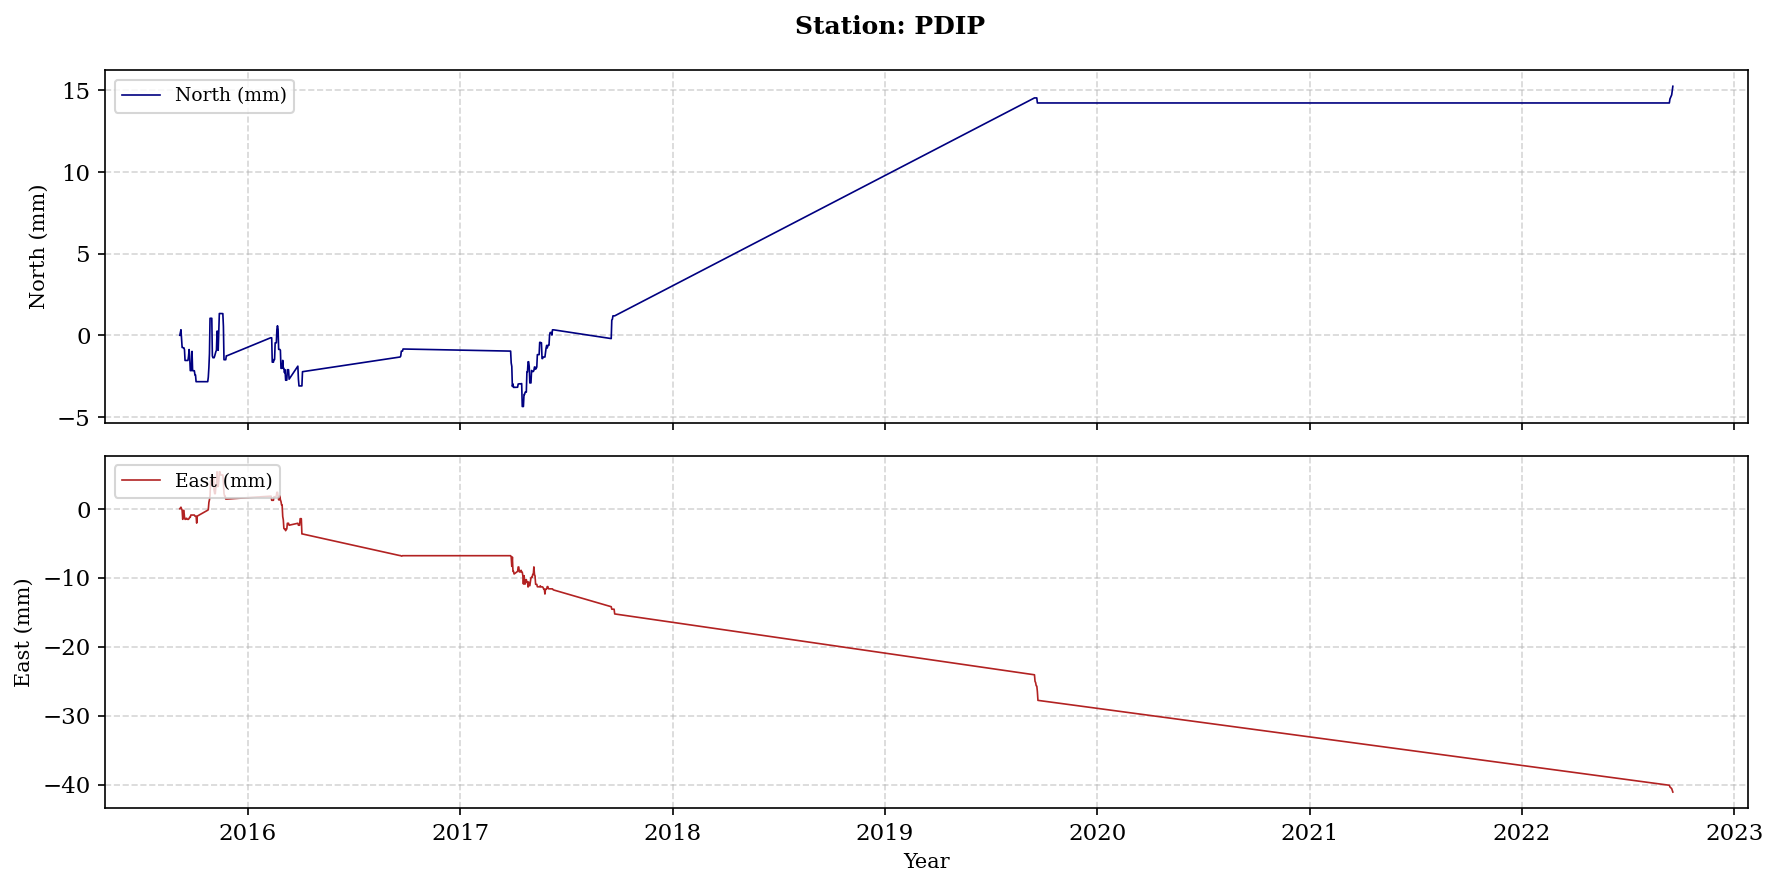

  ✓ PDIP  |  201 epochs


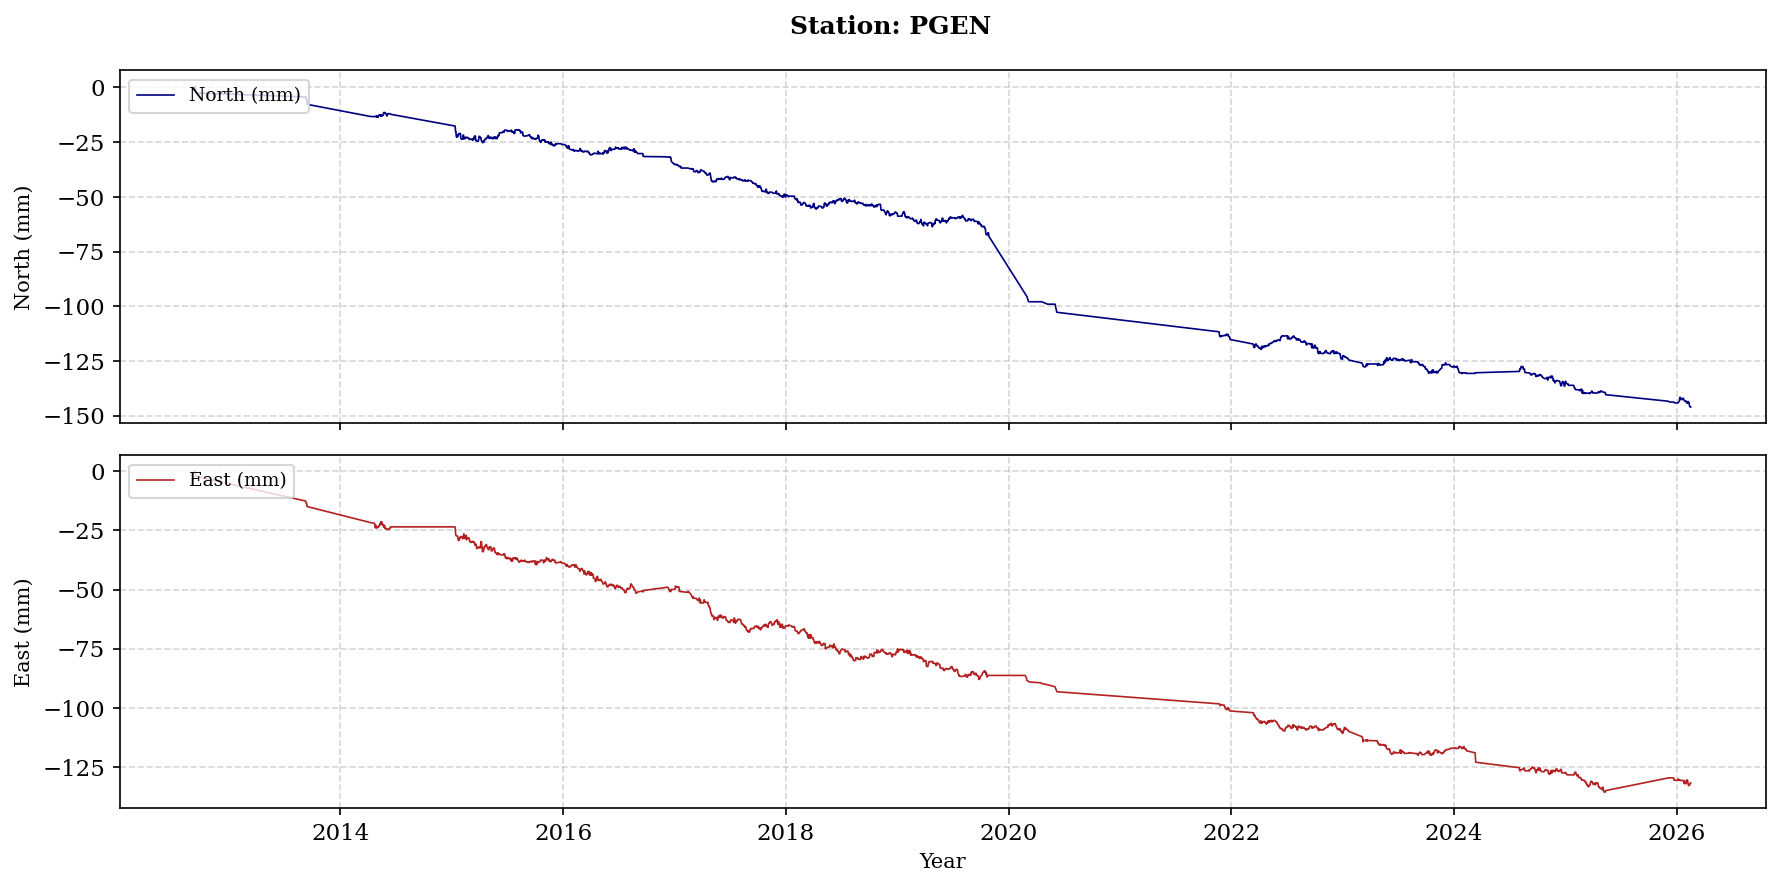

  ✓ PGEN  |  2366 epochs


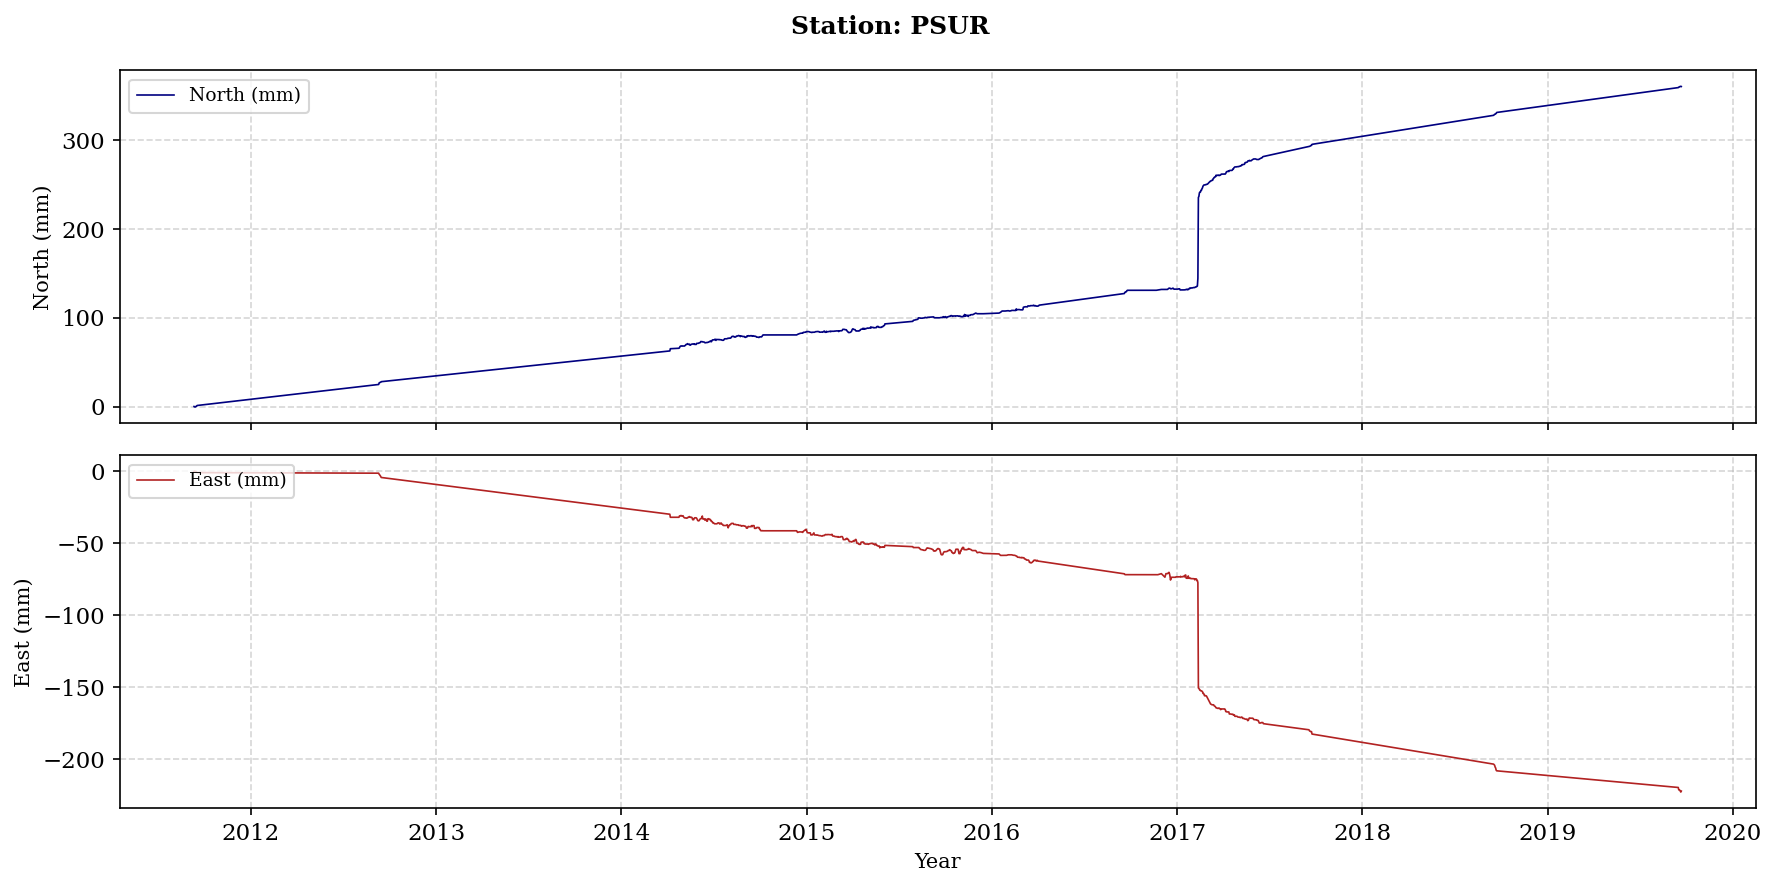

  ✓ PSUR  |  693 epochs


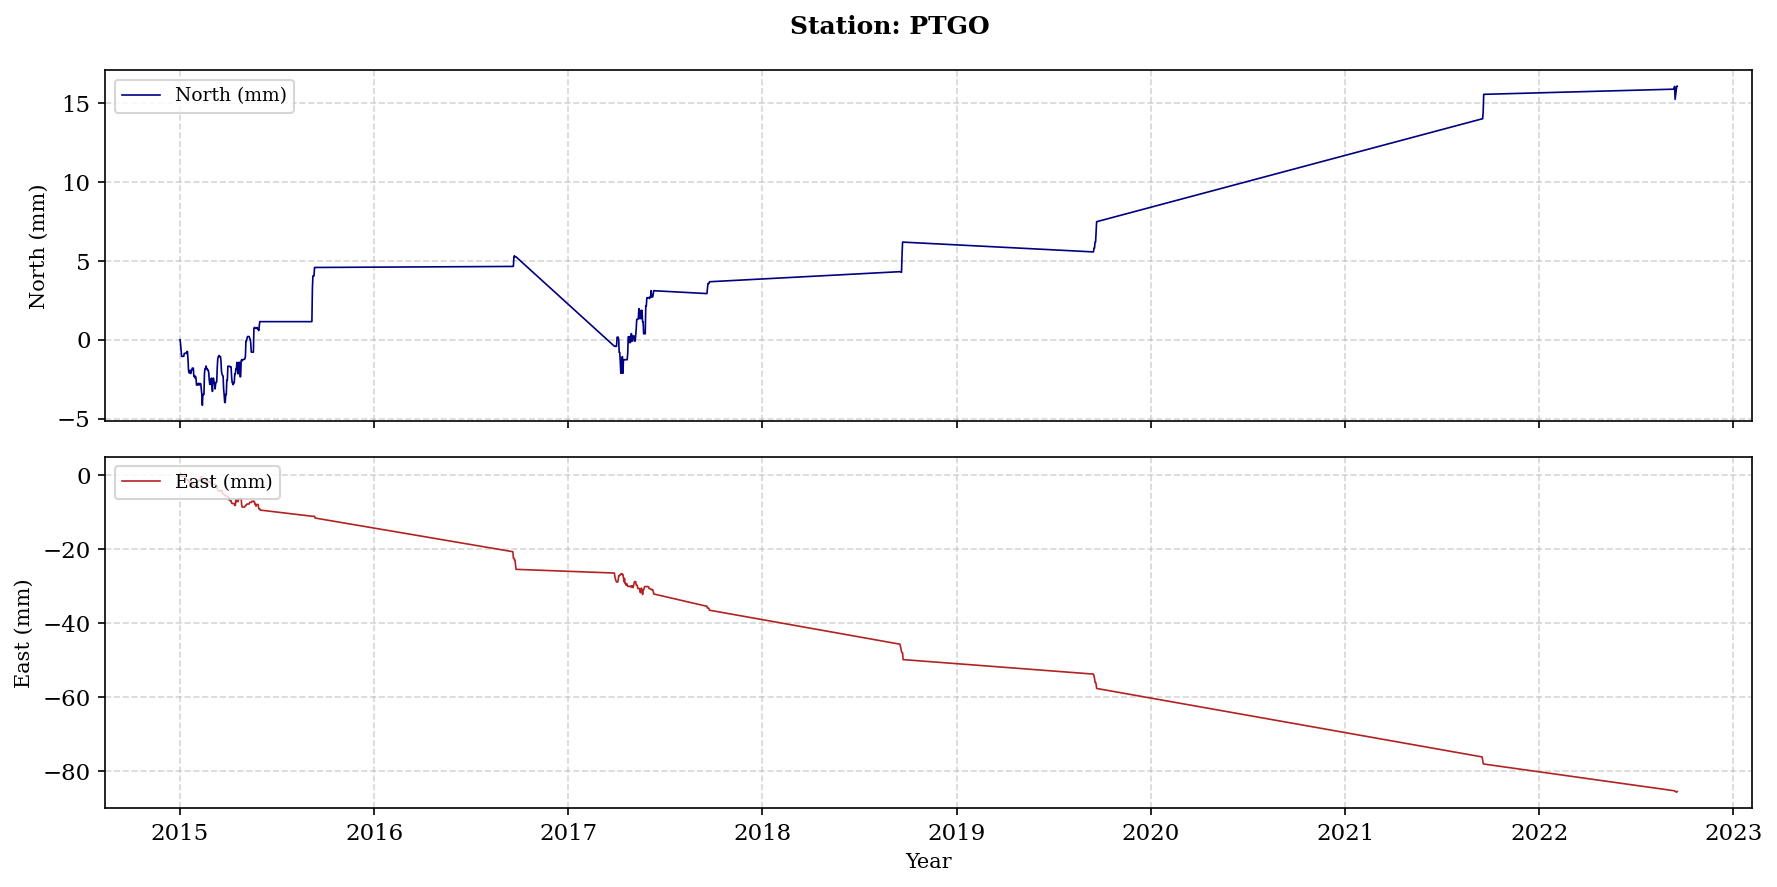

  ✓ PTGO  |  268 epochs


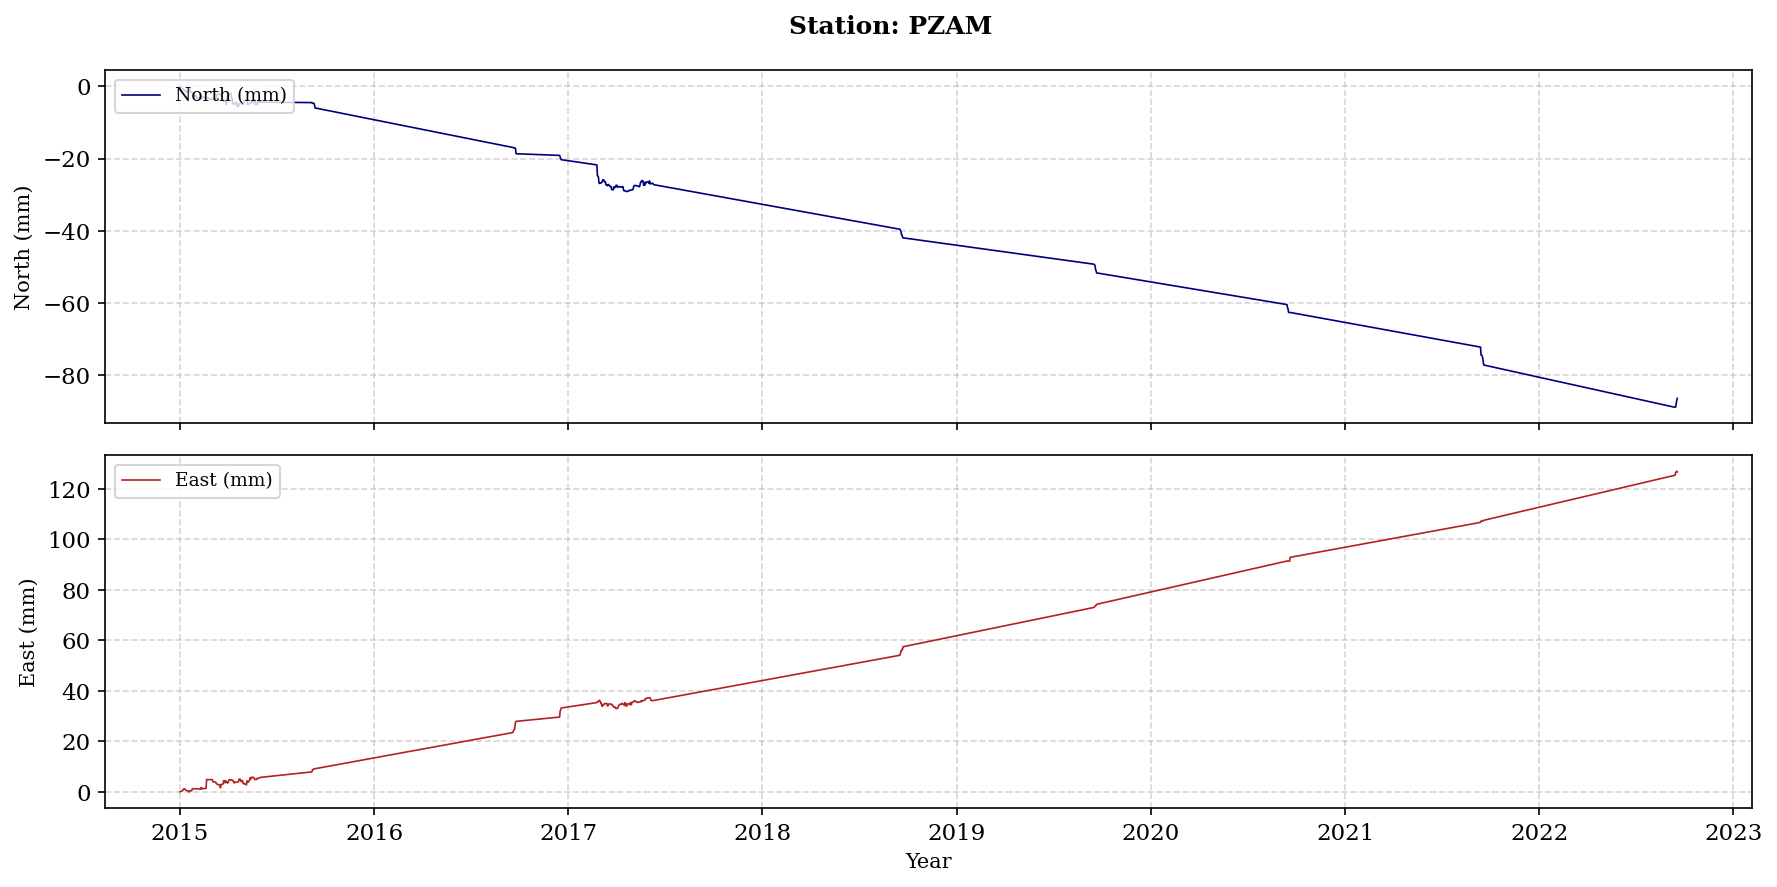

  ✓ PZAM  |  277 epochs

All per-site time series plots complete.
Saved: timeseries_*.png


In [45]:
print("=" * 55)
print("PER-SITE EAST/NORTH TIME SERIES PLOTS")
print("=" * 55)

sites_to_plot = sorted(df['site'].unique())
print(f"Plotting time series for {len(sites_to_plot)} sites: {sites_to_plot}")

for site_id in sites_to_plot:

    site_data = (
        df[df['site'] == site_id]
        .sort_values('decimal_year')
        .copy()
    )

    if len(site_data) < 2:
        print(f"  Skipping {site_id} — insufficient data ({len(site_data)} epochs)")
        continue

    # ── Relative displacement from first epoch ─────────────────
    north_disp = (
        site_data['north'].values -
        site_data['north'].iloc[0]
    )

    east_disp = (
        site_data['east'].values -
        site_data['east'].iloc[0]
    )

    # Convert metres → millimetres
    north_mm = north_disp * 1000
    east_mm  = east_disp  * 1000

    # ── Plot ───────────────────────────────────────────────────
    fig, axes = plt.subplots(
        2, 1,
        figsize=(12,6),
        sharex=True
    )

    fig.suptitle(
        f"Station: {site_id}",
        fontsize=12,
        fontweight='bold'
    )

    # North component
    ax_n = axes[0]

    ax_n.plot(
        site_data['decimal_year'],
        north_mm,
        color='navy',
        linewidth=0.8,
        label='North (mm)'
    )

    ax_n.set_ylabel(
        'North (mm)',
        fontsize=10
    )

    ax_n.legend(
        loc='upper left',
        fontsize=9
    )

    ax_n.grid(
        True,
        linestyle='--',
        alpha=0.5
    )

    # East component
    ax_e = axes[1]

    ax_e.plot(
        site_data['decimal_year'],
        east_mm,
        color='firebrick',
        linewidth=0.8,
        label='East (mm)'
    )

    ax_e.set_ylabel(
        'East (mm)',
        fontsize=10
    )

    ax_e.set_xlabel(
        'Year',
        fontsize=10
    )

    ax_e.legend(
        loc='upper left',
        fontsize=9
    )

    ax_e.grid(
        True,
        linestyle='--',
        alpha=0.5
    )

    plt.tight_layout()

    plt.savefig(
        f"timeseries_{site_id}.png",
        dpi=150,
        bbox_inches='tight'
    )

    plt.show()

    print(
        f"  ✓ {site_id}  |  "
        f"{len(site_data)} epochs"
    )

print("\nAll per-site time series plots complete.")
print("Saved: timeseries_*.png")

## BLOCK 16: SPATIAL INTERPOLATION

In [46]:
"""
BLOCK — GEODETIC VELOCITY TABLE & CSV EXPORT
=============================================
Produces: gnss_velocity_table.csv
Columns needed for spatial interpolation and strain analysis:
  site, latitude, longitude,
  Ve_est  (m/yr), Vn_est  (m/yr),        ← ML-estimated (or LR fallback)
  Ve_mm   (mm/yr), Vn_mm  (mm/yr),       ← unit-converted for readability
  V_horiz (mm/yr),                        ← horizontal speed magnitude
  sig_e, sig_n,                           ← propagated uncertainties
  start_year, end_year, obs_duration_yr,
  data_source                             ← 'ML_estimated' | 'LR_fallback'

The 4 sites excluded by MIN_EPOCHS=50 are recovered here using the
same linear-regression fallback already implemented in Block 16, so
every Mindanao station appears in the output table.

Prerequisites (already run):
  vel_df          – from Block 15 (has Ve_est, Vn_est per epoch)
  combined_df     – raw merged frame from Block 3
  df              – cleaned/filtered frame from Block 4
  site_summary    – from Block 16
  MIN_EPOCHS = 50
"""

import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression

# ── Mindanao station metadata (Table 2 in the thesis) ─────────────────────────
STATION_META = {
    'PBIS': {'location': 'Bislig City',              'lat':  8.189, 'lon': 126.354},
    'PDDN': {'location': 'Tagum City',               'lat':  7.459, 'lon': 125.783},
    'PDAV': {'location': 'Davao City',               'lat':  7.126, 'lon': 125.643},
    'PCOT': {'location': 'Cotabato City',            'lat':  7.200, 'lon': 124.247},
    'DVAO': {'location': 'Davao City',               'lat':  7.072, 'lon': 125.613},
    'PDIG': {'location': 'Digos City',               'lat':  6.760, 'lon': 125.309},
    'PZAM': {'location': 'Zamboanga City',           'lat':  6.929, 'lon': 122.065},
    'PSUR': {'location': 'Surigao City',             'lat':  9.792, 'lon': 125.494},
    'PTCG': {'location': 'Tacurong City',            'lat':  6.693, 'lon': 124.676},
    'PTGO': {'location': 'Tagoloan, Misamis Oriental','lat': 8.526, 'lon': 124.755},
    'PMRM': {'location': 'Maramag, Bukidnon',        'lat':  7.856, 'lon': 125.059},
    'PGEN': {'location': 'Gen. Santos City',         'lat':  6.065, 'lon': 125.132},
    'PMAI': {'location': 'Maitum, Sarangani',        'lat':  6.061, 'lon': 124.496},
    'PDIP': {'location': 'Dipolog City',             'lat':  8.587, 'lon': 123.344},
    'PMAT': {'location': 'Mati City',                'lat':  6.948, 'lon': 126.227},
}

# ── STEP 1: Per-site mean of ML-estimated velocities from vel_df ───────────────
print("=" * 60)
print("GEODETIC VELOCITY TABLE EXPORT")
print("=" * 60)

# Aggregate ML estimates: mean per site (NaNs from LSTM warm-up excluded)
ml_agg = (
    vel_df
    .dropna(subset=['Ve_est', 'Vn_est'])
    .groupby('site')
    .agg(
        latitude        = ('latitude',    'first'),
        longitude       = ('longitude',   'first'),
        Ve_est          = ('Ve_est',       'mean'),
        Vn_est          = ('Vn_est',       'mean'),
        sig_e           = ('sig_e',        'mean'),
        sig_n           = ('sig_n',        'mean'),
        start_year      = ('decimal_year', 'min'),
        end_year        = ('decimal_year', 'max'),
    )
    .reset_index()
)
ml_agg['obs_duration_yr'] = ml_agg['end_year'] - ml_agg['start_year']
ml_agg['data_source']     = 'ML_estimated'

print(f"Sites with ML estimates : {len(ml_agg)}")

# ── STEP 2: Recover dropped sites (< MIN_EPOCHS) using linear regression ───────
sites_in_ml     = set(ml_agg['site'])
all_sites_raw   = set(combined_df['site'].unique())
dropped_sites   = all_sites_raw - sites_in_ml

print(f"Dropped sites to recover: {sorted(dropped_sites)}")

lr_rows = []

# Column-name cleaner (mirrors Block 4)
def clean_cols(frame):
    frame = frame.copy()
    frame.columns = frame.columns.str.strip().str.lower()
    cleaned = []
    for c in frame.columns:
        c = c.replace('__', '').replace('(m)', '').replace('(deg)', '').replace('.', '').strip('_')
        cleaned.append(c)
    frame.columns = cleaned
    if 'longitude'  in frame.columns: frame['longitude']  = frame['longitude'] % 360
    if 'height'     in frame.columns: frame['height']     = pd.to_numeric(frame['height'], errors='coerce')
    if 'yyyyyyyy'   in frame.columns: frame = frame.rename(columns={'yyyyyyyy': 'decimal_year'})
    elif 'yymmmdd'  in frame.columns: frame = frame.rename(columns={'yymmmdd':  'decimal_year'})
    return frame

for site_id in sorted(dropped_sites):
    raw = clean_cols(combined_df[combined_df['site'] == site_id])

    needed = ['site', 'decimal_year', 'east', 'north', 'latitude', 'longitude', 'sig_e', 'sig_n']
    available = [c for c in needed if c in raw.columns]
    raw = raw[available].dropna(subset=['decimal_year', 'east', 'north', 'latitude', 'longitude'])

    if len(raw) < 2:
        print(f"  ✗ {site_id}: only {len(raw)} epochs — skipping entirely.")
        continue

    t      = raw['decimal_year'].values.reshape(-1, 1)
    Ve_lr  = LinearRegression().fit(t, raw['east'].values).coef_[0]
    Vn_lr  = LinearRegression().fit(t, raw['north'].values).coef_[0]

    # Propagated uncertainty: std of residuals / sqrt(N) as a simple estimate
    Ve_resid = raw['east'].values  - (LinearRegression().fit(t, raw['east'].values).predict(t))
    Vn_resid = raw['north'].values - (LinearRegression().fit(t, raw['north'].values).predict(t))
    sig_e_lr = Ve_resid.std() / np.sqrt(len(raw))
    sig_n_lr = Vn_resid.std() / np.sqrt(len(raw))

    # Use known coords from metadata if GNSS-derived coords are suspicious
    meta = STATION_META.get(site_id, {})
    lat  = raw['latitude'].iloc[0]  if abs(raw['latitude'].iloc[0])  < 90  else meta.get('lat', np.nan)
    lon  = raw['longitude'].iloc[0] if 100 < raw['longitude'].iloc[0] < 180 else meta.get('lon', np.nan)

    lr_rows.append({
        'site'           : site_id,
        'latitude'       : lat,
        'longitude'      : lon,
        'Ve_est'         : Ve_lr,
        'Vn_est'         : Vn_lr,
        'sig_e'          : sig_e_lr,
        'sig_n'          : sig_n_lr,
        'start_year'     : raw['decimal_year'].min(),
        'end_year'       : raw['decimal_year'].max(),
        'obs_duration_yr': raw['decimal_year'].max() - raw['decimal_year'].min(),
        'data_source'    : 'LR_fallback',
    })
    print(f"  ✓ {site_id}: Ve={Ve_lr*1000:+.3f} mm/yr  Vn={Vn_lr*1000:+.3f} mm/yr  "
          f"(n={len(raw)} epochs)")

lr_df = pd.DataFrame(lr_rows)

# ── STEP 3: Merge ML + LR rows ─────────────────────────────────────────────────
geodetic_table = pd.concat([ml_agg, lr_df], ignore_index=True)

# ── STEP 4: Enrich with location names & unit conversions ─────────────────────
geodetic_table['location'] = geodetic_table['site'].map(
    lambda s: STATION_META.get(s, {}).get('location', '')
)

# Override lat/lon from trusted metadata where the data-derived coords are NaN
for idx, row in geodetic_table.iterrows():
    meta = STATION_META.get(row['site'], {})
    if pd.isna(row['latitude'])  and 'lat' in meta:
        geodetic_table.at[idx, 'latitude']  = meta['lat']
    if pd.isna(row['longitude']) and 'lon' in meta:
        geodetic_table.at[idx, 'longitude'] = meta['lon']

# Unit conversions (m/yr → mm/yr)
geodetic_table['Ve_mm']    = geodetic_table['Ve_est'] * 1000
geodetic_table['Vn_mm']    = geodetic_table['Vn_est'] * 1000
geodetic_table['V_horiz']  = np.sqrt(geodetic_table['Ve_mm']**2 + geodetic_table['Vn_mm']**2)

# Uncertainty in mm/yr
geodetic_table['sig_e_mm'] = geodetic_table['sig_e'] * 1000
geodetic_table['sig_n_mm'] = geodetic_table['sig_n'] * 1000

# Azimuth of horizontal velocity (degrees clockwise from North, 0–360)
geodetic_table['azimuth_deg'] = (
    np.degrees(np.arctan2(geodetic_table['Ve_mm'], geodetic_table['Vn_mm'])) % 360
)

# ── STEP 5: Column order – exactly what the geodetic needs ────────────────────
EXPORT_COLS = [
    'site', 'location',
    'latitude', 'longitude',
    'Ve_mm', 'Vn_mm',           # velocity components (mm/yr)  ← spatial interp input
    'V_horiz',                  # horizontal speed magnitude (mm/yr)
    'azimuth_deg',              # direction of motion
    'sig_e_mm', 'sig_n_mm',     # 1-σ uncertainties (mm/yr)
    'Ve_est', 'Vn_est',         # raw m/yr (kept for strain computation)
    'start_year', 'end_year', 'obs_duration_yr',
    'data_source',
]
geodetic_table = geodetic_table[EXPORT_COLS].sort_values('site').reset_index(drop=True)

# ── STEP 6: Save CSV ───────────────────────────────────────────────────────────
OUT_CSV = "gnss_velocity_table.csv"
geodetic_table.round(6).to_csv(OUT_CSV, index=False)
print(f"\nSaved: {OUT_CSV}  ({len(geodetic_table)} stations)")

# ── STEP 7: Display table ──────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("GNSS VELOCITY TABLE (all stations)")
print("=" * 60)

display_cols = [
    'site', 'location', 'latitude', 'longitude',
    'Ve_mm', 'Vn_mm', 'V_horiz', 'azimuth_deg',
    'sig_e_mm', 'sig_n_mm',
    'obs_duration_yr', 'data_source',
]

display(
    geodetic_table[display_cols]
    .round({'latitude': 4, 'longitude': 4,
            'Ve_mm': 3, 'Vn_mm': 3, 'V_horiz': 3,
            'azimuth_deg': 1,
            'sig_e_mm': 4, 'sig_n_mm': 4,
            'obs_duration_yr': 2})
    .style
    .set_caption("GNSS Horizontal Velocity Field — Mindanao PAGeNet Stations")
    .format({
        'Ve_mm'         : '{:+.3f}',
        'Vn_mm'         : '{:+.3f}',
        'V_horiz'       : '{:.3f}',
        'azimuth_deg'   : '{:.1f}°',
        'sig_e_mm'      : '±{:.4f}',
        'sig_n_mm'      : '±{:.4f}',
        'obs_duration_yr': '{:.2f} yr',
    })
    .applymap(lambda v: 'background-color: #fff3cd', subset=['data_source'])
    .set_table_styles([
        {'selector': 'th', 'props': [('font-size', '11px'), ('text-align', 'center')]},
        {'selector': 'td', 'props': [('font-size', '11px')]},
    ])
)

# ── STEP 8: Quick sanity check ─────────────────────────────────────────────────
print("\n── Sanity check ────────────────────────────────────────────")
print(f"  Total stations        : {len(geodetic_table)}")
print(f"  ML-estimated          : {(geodetic_table['data_source']=='ML_estimated').sum()}")
print(f"  LR fallback (dropped) : {(geodetic_table['data_source']=='LR_fallback').sum()}")
print(f"  Ve range (mm/yr)      : {geodetic_table['Ve_mm'].min():+.3f} → {geodetic_table['Ve_mm'].max():+.3f}")
print(f"  Vn range (mm/yr)      : {geodetic_table['Vn_mm'].min():+.3f} → {geodetic_table['Vn_mm'].max():+.3f}")
print(f"  V_horiz range (mm/yr) : {geodetic_table['V_horiz'].min():.3f} → {geodetic_table['V_horiz'].max():.3f}")
print(f"  Any NaN coords?       : {geodetic_table[['latitude','longitude']].isna().any().any()}")
print(f"  Any NaN velocities?   : {geodetic_table[['Ve_mm','Vn_mm']].isna().any().any()}")

print("\n── Ready for ──────────────────────────────────────────────")
print("  ✓  Spatial interpolation  →  feed Ve_mm, Vn_mm, lat, lon into Kriging/IDW")
print("  ✓  Strain tensor computation  →  use Ve_est, Vn_est (m/yr) with np.gradient")
print("  ✓  Velocity vector map  →  quiver(lon, lat, Ve_mm, Vn_mm)")

GEODETIC VELOCITY TABLE EXPORT
Sites with ML estimates : 10
Dropped sites to recover: ['PMAI', 'PMRM', 'PTCG']
  ✓ PMAI: Ve=+82.576 mm/yr  Vn=+267.786 mm/yr  (n=7 epochs)
  ✓ PMRM: Ve=-17.010 mm/yr  Vn=+0.685 mm/yr  (n=22 epochs)
  ✓ PTCG: Ve=-12.843 mm/yr  Vn=-7.989 mm/yr  (n=14 epochs)

Saved: gnss_velocity_table.csv  (13 stations)

GNSS VELOCITY TABLE (all stations)


,site,location,latitude,longitude,Ve_mm,Vn_mm,V_horiz,azimuth_deg,sig_e_mm,sig_n_mm,obs_duration_yr,data_source
0,DVAO,Davao City,7.071900,125.612900,-30.514,-1.609,30.556,267.0°,±0.9059,±0.7765,8.59 yr,ML_estimated
1,PBIS,Bislig City,8.189200,126.353900,-30.676,+20.573,36.936,303.8°,±0.8800,±0.7712,6.98 yr,ML_estimated
2,PCOT,Cotabato City,7.199600,124.247000,-18.728,-10.900,21.669,239.8°,±1.0468,±0.8882,7.52 yr,ML_estimated
3,PDAV,Davao City,7.126500,125.643400,-33.938,+1.547,33.973,272.6°,±0.9174,±0.7985,6.62 yr,ML_estimated
4,PDDN,Tagum City,7.459400,125.783300,-28.942,+1.029,28.961,272.0°,±0.9564,±0.8378,2.00 yr,ML_estimated
5,PDIP,Dipolog City,8.586800,123.344300,-4.534,+6.393,7.837,324.7°,±0.8277,±0.7300,6.89 yr,ML_estimated
6,PGEN,Gen. Santos City,6.064900,125.131700,-11.248,-7.755,13.662,235.4°,±0.9383,±0.8168,11.77 yr,ML_estimated
7,PMAI,"Maitum, Sarangani",6.061300,124.495600,+82.576,+267.786,280.229,17.1°,±0.6520,±0.9126,0.02 yr,LR_fallback
8,PMRM,"Maramag, Bukidnon",7.856300,125.058700,-17.010,+0.685,17.024,272.3°,±0.2172,±0.8687,3.99 yr,LR_fallback
9,PSUR,Surigao City,9.791800,125.493700,-65.772,+95.056,115.592,325.3°,±0.8839,±0.7729,5.37 yr,ML_estimated



── Sanity check ────────────────────────────────────────────
  Total stations        : 13
  ML-estimated          : 10
  LR fallback (dropped) : 3
  Ve range (mm/yr)      : -65.772 → +82.576
  Vn range (mm/yr)      : -10.900 → +267.786
  V_horiz range (mm/yr) : 7.837 → 280.229
  Any NaN coords?       : False
  Any NaN velocities?   : False

── Ready for ──────────────────────────────────────────────
  ✓  Spatial interpolation  →  feed Ve_mm, Vn_mm, lat, lon into Kriging/IDW
  ✓  Strain tensor computation  →  use Ve_est, Vn_est (m/yr) with np.gradient
  ✓  Velocity vector map  →  quiver(lon, lat, Ve_mm, Vn_mm)


## BLOCK 17: VELOCITY FIELD MAP

Using geodetic_table from memory.


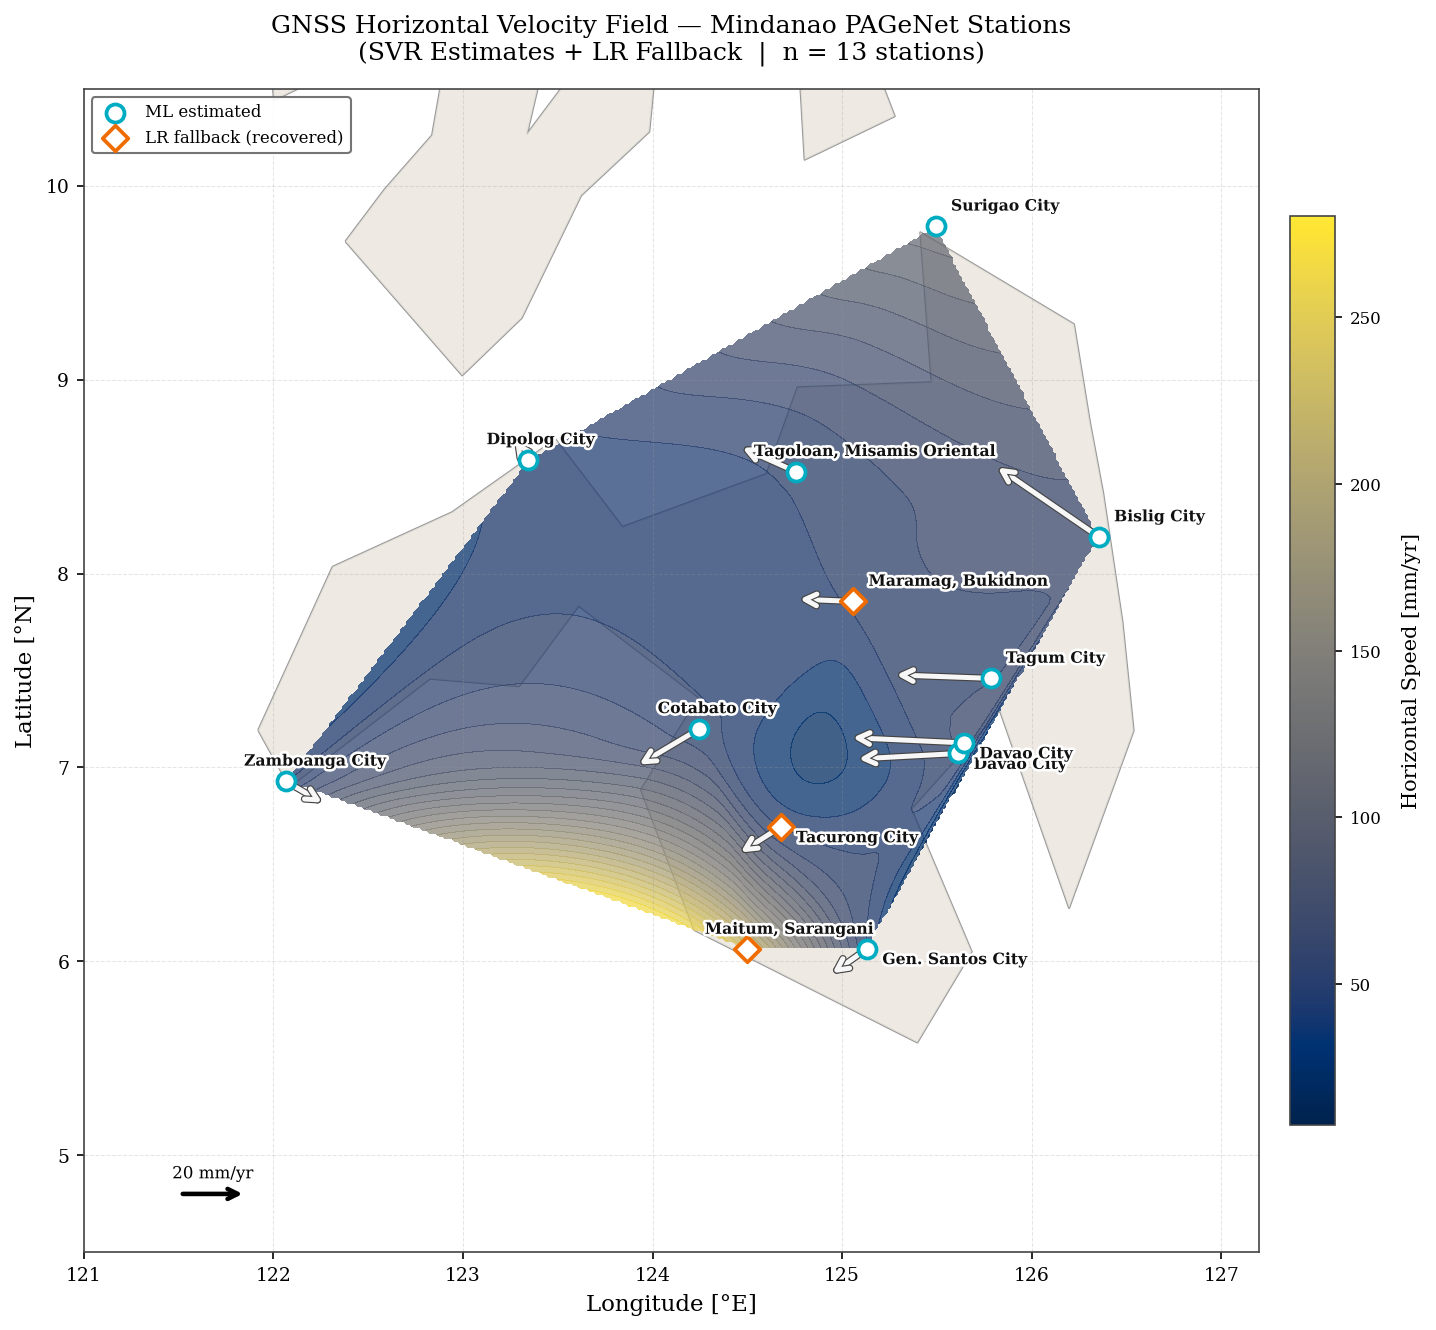

In [47]:
import matplotlib.patches as mpatches
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
import matplotlib.patheffects as pe
from scipy.interpolate import griddata

# New Imports for Mindanao outline
import geopandas as gpd

# Add requests and zipfile for downloading data
import requests
import zipfile
import os
import io

# Load data (from memory if available, else from CSV)
try:
    vt = geodetic_table.copy()
    print("Using geodetic_table from memory.")
except NameError:
    vt = pd.read_csv("gnss_velocity_table.csv")
    print("Loaded gnss_velocity_table.csv from disk.")

lons   = vt['longitude'].values
lats   = vt['latitude'].values
Ve     = vt['Ve_mm'].values          # mm/yr
Vn     = vt['Vn_mm'].values          # mm/yr
Vmag   = vt['V_horiz'].values        # mm/yr
sites  = vt['site'].values
source = vt['data_source'].values

# Background: interpolate V_horiz onto a fine grid
pad = 0.4
xi  = np.linspace(lons.min() - pad, lons.max() + pad, 300)
yi  = np.linspace(lats.min() - pad, lats.max() + pad, 300)
XI, YI = np.meshgrid(xi, yi)

Vmag_grid = griddata(
    (lons, lats),
    Vmag,
    (XI, YI),
    method='cubic'
)

# Figure
fig, ax = plt.subplots(figsize=(11, 9))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

# Mindanao outline / coastline
url = "https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip"
world = gpd.read_file(url)

philippines = world[world["ADMIN"] == "Philippines"]

philippines.boundary.plot(
    ax=ax,
    color='#555555',
    linewidth=1.0,
    alpha=0.6,
    zorder=0
)

philippines.plot(
    ax=ax,
    color='#ebe7df',
    alpha=0.85,
    edgecolor='none',
    zorder=0
)

# Background magnitude field
cf = ax.contourf(
    XI,
    YI,
    Vmag_grid,
    levels=30,
    cmap='cividis',
    alpha=0.72,
    zorder=1
)

# Faint grid
ax.grid(
    color='#999999',
    linewidth=0.5,
    alpha=0.25,
    linestyle='--',
    zorder=2
)

# Velocity arrows
SCALE_MM = 0.018

# Normalize arrow colour by speed
norm = Normalize(vmin=Vmag.min(), vmax=Vmag.max())
cmap = plt.cm.plasma
colors_arr = cmap(norm(Vmag))

for i in range(len(lons)):
    ax.annotate(
        '',
        xy=(
            lons[i] + Ve[i] * SCALE_MM,
            lats[i] + Vn[i] * SCALE_MM
        ),
        xytext=(lons[i], lats[i]),
        arrowprops=dict(
            arrowstyle='->',
            color='#f7f7f7',
            lw=2.4,
            mutation_scale=14,
            path_effects=[
                pe.withStroke(
                    linewidth=3.5,
                    foreground='#444444'
                )
            ]
        ),
        zorder=5,
    )

# Station markers
ml_mask = source == 'ML_estimated'
lr_mask = source == 'LR_fallback'

ax.scatter(
    lons[ml_mask],
    lats[ml_mask],
    s=75,
    color='white',
    edgecolors='#00acc1',
    linewidths=1.8,
    zorder=6,
    label='ML estimated'
)

ax.scatter(
    lons[lr_mask],
    lats[lr_mask],
    s=75,
    color='white',
    edgecolors='#ef6c00',
    linewidths=1.8,
    marker='D',
    zorder=6,
    label='LR fallback (recovered)'
)

# Station labels
label_offsets = {
    'PBIS': ( 0.08, 0.06),
    'PDDN': ( 0.08, 0.06),
    'PDAV': ( 0.08,-0.10),
    'PCOT': (-0.22, 0.06),
    'DVAO': ( 0.08,-0.10),
    'PDIG': ( 0.08, 0.06),
    'PZAM': (-0.22, 0.06),
    'PSUR': ( 0.08, 0.06),
    'PTCG': ( 0.08,-0.10),
    'PTGO': (-0.22, 0.06),
    'PMRM': ( 0.08, 0.06),
    'PGEN': ( 0.08,-0.10),
    'PMAI': (-0.22, 0.06),
    'PDIP': (-0.22, 0.06),
    'PMAT': ( 0.08, 0.06),
}

for i in range(len(sites)):
    sid = sites[i]

    dx, dy = label_offsets.get(sid, (0.07, 0.06))

    city_name = STATION_META.get(
        sid,
        {}
    ).get('location', sid)

    txt = ax.text(
        lons[i] + dx,
        lats[i] + dy,
        city_name,
        fontsize=7.5,
        color='#111111',
        fontweight='bold',
        ha='left',
        va='bottom',
        zorder=7,
    )

    txt.set_path_effects([
        pe.withStroke(
            linewidth=2.5,
            foreground='white'
        )
    ])

# Reference arrow
ref_lon, ref_lat = 121.5, 4.8
ref_mm = 20

ax.annotate(
    '',
    xy=(ref_lon + ref_mm * SCALE_MM, ref_lat),
    xytext=(ref_lon, ref_lat),
    arrowprops=dict(
        arrowstyle='->',
        color='black',
        lw=2.2,
        mutation_scale=12
    ),
    zorder=8,
)

ax.text(
    ref_lon + ref_mm * SCALE_MM / 2,
    ref_lat + 0.06,
    f'{ref_mm} mm/yr',
    color='black',
    fontsize=8,
    ha='center',
    va='bottom',
    zorder=8,
    path_effects=[
        pe.withStroke(
            linewidth=2,
            foreground='white'
        )
    ]
)

# Colorbar
sm = ScalarMappable(cmap='cividis', norm=norm)
sm.set_array([])

cbar = fig.colorbar(
    sm,
    ax=ax,
    fraction=0.03,
    pad=0.02
)

cbar.set_label(
    'Horizontal Speed [mm/yr]',
    color='black',
    fontsize=10,
    labelpad=10
)

cbar.ax.yaxis.set_tick_params(color='black')

plt.setp(
    cbar.ax.yaxis.get_ticklabels(),
    color='black',
    fontsize=8
)

cbar.outline.set_edgecolor('#444444')

# Labels & legend
ax.set_xlabel(
    'Longitude [°E]',
    color='black',
    fontsize=11
)

ax.set_ylabel(
    'Latitude [°N]',
    color='black',
    fontsize=11
)

ax.tick_params(
    colors='black',
    labelsize=9
)

for spine in ax.spines.values():
    spine.set_edgecolor('#444444')

# Set plot limits
ax.set_xlim(121.0, 127.2)
ax.set_ylim(4.5, 10.5)

legend = ax.legend(
    loc='upper left',
    fontsize=8,
    framealpha=0.9,
    facecolor='white',
    edgecolor='#666666',
    labelcolor='black'
)

ax.set_title(
    'GNSS Horizontal Velocity Field — Mindanao PAGeNet Stations\n'
    f'({best_model_name if "best_model_name" in dir() else "ML"} Estimates + LR Fallback  |  '
    f'n = {len(vt)} stations)',
    color='black',
    fontsize=12,
    pad=14,
)

plt.tight_layout()

plt.savefig(
    'velocity_field_map.png',
    dpi=220,
    bbox_inches='tight',
    facecolor='white'
)

plt.show()

## BLOCK 18: STRAIN TENSOR COMPUTATION

In [48]:
from scipy.interpolate import RegularGridInterpolator
from scipy.ndimage import gaussian_filter

try:
    from pykrige.ok import OrdinaryKriging
    PYKRIGE_AVAILABLE = True
except ImportError:
    PYKRIGE_AVAILABLE = False

from sklearn.neighbors import BallTree

print("=" * 60)
print("STRAIN RATE TABLE & CSV EXPORT")
print("=" * 60)

# ── STEP 1: Load velocity table produced by the previous block ────────────────
vel_table = pd.read_csv("gnss_velocity_table.csv")

# Define lons_st and lats_st from vel_table
lons_st  = vel_table['longitude'].values
lats_st  = vel_table['latitude'].values

# Robust velocity clipping to suppress unrealistic gradients
VEL_LIMIT = 60.0 / 1000.0   # 60 mm/yr → m/yr

Ve_st = np.clip(
    vel_table['Ve_est'].values,
    -VEL_LIMIT,
    VEL_LIMIT
)

Vn_st = np.clip(
    vel_table['Vn_est'].values,
    -VEL_LIMIT,
    VEL_LIMIT
)

print(f"  Loaded {len(vel_table)} stations from gnss_velocity_table.csv")
print(f"  ML-estimated : {(vel_table['data_source']=='ML_estimated').sum()}")
print(f"  LR fallback  : {(vel_table['data_source']=='LR_fallback').sum()}")

# ── STEP 2: Spatial interpolation → continuous Ve/Vn grids ────────────────────
GRID_RES = 100

pad_lon = (lons_st.max() - lons_st.min()) * 0.10 or 0.5
pad_lat = (lats_st.max() - lats_st.min()) * 0.10 or 0.5

grid_lon_1d = np.linspace(lons_st.min() - pad_lon, lons_st.max() + pad_lon, GRID_RES)
grid_lat_1d = np.linspace(lats_st.min() - pad_lat, lats_st.max() + pad_lat, GRID_RES)
grid_lon, grid_lat = np.meshgrid(grid_lon_1d, grid_lat_1d)

print(f"\n  Grid: {GRID_RES}×{GRID_RES}  |  "
      f"Lon {grid_lon_1d.min():.3f}→{grid_lon_1d.max():.3f}  |  "
      f"Lat {grid_lat_1d.min():.3f}→{grid_lat_1d.max():.3f}")

if PYKRIGE_AVAILABLE:
    print("  Interpolation method : Ordinary Kriging (spherical variogram)")
    ok_Ve = OrdinaryKriging(lons_st, lats_st, Ve_st,
                            variogram_model='linear',
                            verbose=False, enable_plotting=False)
    ok_Vn = OrdinaryKriging(lons_st, lats_st, Vn_st,
                            variogram_model='linear',
                            verbose=False, enable_plotting=False)
    Ve_grid, _ = ok_Ve.execute('grid', grid_lon_1d, grid_lat_1d)
    Vn_grid, _ = ok_Vn.execute('grid', grid_lon_1d, grid_lat_1d)
    Ve_grid = np.array(Ve_grid)
    Vn_grid = np.array(Vn_grid)
    interp_method = 'Ordinary Kriging'
else:
    print("  Interpolation method : IDW (power=2, haversine BallTree)")
    def idw_interpolate(lons_s, lats_s, values, glon, glat, power=2):
        pts  = np.column_stack([lons_s, lats_s])
        gpts = np.column_stack([glon.ravel(), glat.ravel()])
        tree = BallTree(np.deg2rad(pts), metric='haversine')
        dist, idx = tree.query(np.deg2rad(gpts), k=min(8, len(pts)))
        dist = np.where(dist == 0, 1e-10, dist)
        w    = 1.0 / dist**power
        result = (w * values[idx]).sum(axis=1) / w.sum(axis=1)
        return result.reshape(glon.shape)

    Ve_grid = idw_interpolate(lons_st, lats_st, Ve_st, grid_lon, grid_lat)
    Vn_grid = idw_interpolate(lons_st, lats_st, Vn_st, grid_lon, grid_lat)
    interp_method = 'IDW (power=2)'

print("  Interpolation complete.")

# Smooth velocity grids before spatial differentiation
# Reduces interpolation ringing and unstable strain gradients
Ve_grid = gaussian_filter(Ve_grid, sigma=1.2)
Vn_grid = gaussian_filter(Vn_grid, sigma=1.2)

print("  Gaussian smoothing applied (sigma=1.2)")

# ── STEP 3: Strain tensor computation (matches Block 20 exactly) ───────────────
print("\n  Computing strain tensor ...")

R_EARTH       = 6_371_000.0                          # m
lat_mean_rad  = np.deg2rad(np.mean(grid_lat))
m_per_deg_lat = np.pi * R_EARTH / 180.0
m_per_deg_lon = m_per_deg_lat * np.cos(lat_mean_rad)

dlat_m = abs(grid_lat[1, 0] - grid_lat[0, 0]) * m_per_deg_lat   # metres per grid step (N)
dlon_m = abs(grid_lon[0, 1] - grid_lon[0, 0]) * m_per_deg_lon   # metres per grid step (E)

# np.gradient: axis-0 = latitude (N direction), axis-1 = longitude (E direction)
dVe_dy, dVe_dx = np.gradient(Ve_grid, dlat_m, dlon_m)
dVn_dy, dVn_dx = np.gradient(Vn_grid, dlat_m, dlon_m)

epsilon_xx = dVe_dx                                    # ∂Ve/∂x
epsilon_yy = dVn_dy                                    # ∂Vn/∂y
epsilon_xy = 0.5 * (dVe_dy + dVn_dx)                  # ½(∂Ve/∂y + ∂Vn/∂x)

dilatation = epsilon_xx + epsilon_yy
max_shear  = 0.5 * np.sqrt((epsilon_xx - epsilon_yy)**2
                            + 4 * epsilon_xy**2)
second_inv = np.sqrt(epsilon_xx**2 + epsilon_yy**2 + 2 * epsilon_xy**2)

# Principal strain rates (eigenvalues of the symmetric strain tensor)
avg  = (epsilon_xx + epsilon_yy) / 2.0
disc = np.sqrt(((epsilon_xx - epsilon_yy) / 2.0)**2 + epsilon_xy**2)
lambda1 = avg + disc      # maximum principal strain rate
lambda2 = avg - disc      # minimum principal strain rate

# Azimuth of λ1 axis (angle of max extension, °CW from North)
# half-angle from the tensor eigenvector formula, converted to geographic bearing
theta_rad    = 0.5 * np.arctan2(2.0 * epsilon_xy, epsilon_xx - epsilon_yy)
principal_az = (90.0 - np.degrees(theta_rad)) % 180   # 0–180° (undirected axis)

NANO = 1e9   # convert m/yr/m → nanostrain/yr

strain_grids = {
    'epsilon_xx' : epsilon_xx  * NANO,
    'epsilon_yy' : epsilon_yy  * NANO,
    'epsilon_xy' : epsilon_xy  * NANO,
    'dilatation' : dilatation  * NANO,
    'max_shear'  : max_shear   * NANO,
    'second_inv' : second_inv  * NANO,
    'lambda1'    : lambda1     * NANO,
    'lambda2'    : lambda2     * NANO,
    'principal_az': principal_az,      # degrees — no NANO conversion
}

# Robust strain clipping to suppress interpolation-induced outliers
STRAIN_CAP = 500.0   # nanostrain/yr

for key in [
    'epsilon_xx',
    'epsilon_yy',
    'epsilon_xy',
    'dilatation',
    'max_shear',
    'second_inv',
    'lambda1',
    'lambda2'
]:
    if key in ['max_shear', 'second_inv']:
        strain_grids[key] = np.clip(
            strain_grids[key],
            0,
            STRAIN_CAP
        )
    else:
        strain_grids[key] = np.clip(
            strain_grids[key],
            -STRAIN_CAP,
            STRAIN_CAP
        )

print("  Strain tensor summary [nanostrain/yr]:")
for key, arr in strain_grids.items():
    unit = '°' if key == 'principal_az' else 'nstr/yr'
    print(f"    {key:14s}  min={arr.min():+10.4f}  max={arr.max():+10.4f}  "
          f"mean={arr.mean():+10.4f}  [{unit}]")

# ── STEP 4: Per-station strain (interpolate grid → station coordinates) ────────
print("\n  Sampling strain at station coordinates ...")

def sample_grid(grid_2d, grid_lon_1d, grid_lat_1d, query_lons, query_lats):
    """Bilinear interpolation of a 2-D grid at arbitrary (lon, lat) points."""
    interp = RegularGridInterpolator(
        (grid_lat_1d, grid_lon_1d),   # axes must match grid_2d shape (row=lat, col=lon)
        grid_2d,
        method='linear',
        bounds_error=False,
        fill_value=np.nan,
    )
    return interp(np.column_stack([query_lats, query_lons]))

station_strain = vel_table[['site', 'location', 'latitude', 'longitude',
                             'Ve_mm', 'Vn_mm', 'V_horiz',
                             'obs_duration_yr', 'data_source']].copy()

for key, grid_2d in strain_grids.items():
    station_strain[key] = sample_grid(
        grid_2d, grid_lon_1d, grid_lat_1d,
        lons_st, lats_st
    )

# Tectonic activity classification based on second invariant (nanostrain/yr)
# Thresholds follow Kreemer et al. (2014) convention adapted for regional GNSS
def classify_strain(val):
    if pd.isna(val):
        return 'No data'
    elif val < 20:
        return 'Low'
    elif val < 80:
        return 'Moderate'
    elif val < 200:
        return 'High'
    else:
        return 'Very High'

station_strain['strain_class'] = station_strain['second_inv'].map(classify_strain)
station_strain['interp_method'] = interp_method

# ── STEP 5: Export per-station CSV ────────────────────────────────────────────
STATION_COLS = [
    'site', 'location',
    'latitude', 'longitude',
    'Ve_mm', 'Vn_mm', 'V_horiz',
    'epsilon_xx', 'epsilon_yy', 'epsilon_xy',
    'dilatation', 'max_shear', 'second_inv',
    'lambda1', 'lambda2', 'principal_az',
    'strain_class',
    'obs_duration_yr', 'data_source', 'interp_method',
]

station_strain[STATION_COLS].round(6).to_csv("gnss_strain_per_station.csv", index=False)
print("  Saved: gnss_strain_per_station.csv")

# ── STEP 6: Export full grid CSV (for QGIS / GIS import) ─────────────────────
grid_rows = {
    'longitude'  : grid_lon.ravel(),
    'latitude'   : grid_lat.ravel(),
    'Ve_est_myr' : Ve_grid.ravel(),
    'Vn_est_myr' : Vn_grid.ravel(),
}
for key, grid_2d in strain_grids.items():
    grid_rows[key] = grid_2d.ravel()

grid_df = pd.DataFrame(grid_rows)
grid_df['strain_class'] = grid_df['second_inv'].map(classify_strain)
grid_df.round(8).to_csv("gnss_strain_grid.csv", index=False)
print(f"  Saved: gnss_strain_grid.csv  ({len(grid_df):,} grid cells)")

# ── STEP 7: Display per-station table ─────────────────────────────────────────
print("\n" + "=" * 60)
print("STRAIN RATE TABLE — per GNSS station (nanostrain/yr)")
print("=" * 60)

display_cols = [
    'site', 'location',
    'latitude', 'longitude',
    'epsilon_xx', 'epsilon_yy', 'epsilon_xy',
    'dilatation', 'max_shear', 'second_inv',
    'lambda1', 'lambda2', 'principal_az',
    'strain_class', 'data_source',
]

round_spec = {c: 4 for c in [
    'epsilon_xx','epsilon_yy','epsilon_xy',
    'dilatation','max_shear','second_inv',
    'lambda1','lambda2'
]}
round_spec.update({'latitude': 4, 'longitude': 4, 'principal_az': 1})

def _color_class(val):
    colors = {
        'Low'      : 'background-color: #d4edda; color: #155724',
        'Moderate' : 'background-color: #fff3cd; color: #856404',
        'High'     : 'background-color: #ffd5b8; color: #7a3e00',
        'Very High': 'background-color: #f8d7da; color: #721c24',
        'No data'  : 'background-color: #e2e3e5; color: #383d41',
    }
    return colors.get(val, '')

display(
    station_strain[display_cols]
    .sort_values('site')
    .reset_index(drop=True)
    .round(round_spec)
    .style
    .set_caption(
        f"Horizontal Strain Rate Tensor — Mindanao PAGeNet Stations  "
        f"[nanostrain yr⁻¹]  |  Interpolation: {interp_method}"
    )
    .format({
        'epsilon_xx'  : '{:+.4f}',
        'epsilon_yy'  : '{:+.4f}',
        'epsilon_xy'  : '{:+.4f}',
        'dilatation'  : '{:+.4f}',
        'max_shear'   : '{:.4f}',
        'second_inv'  : '{:.4f}',
        'lambda1'     : '{:+.4f}',
        'lambda2'     : '{:+.4f}',
        'principal_az': '{:.1f}°',
    })
    .applymap(_color_class, subset=['strain_class'])
    .set_table_styles([
        {'selector': 'th', 'props': [('font-size', '10px'), ('text-align', 'center')]},
        {'selector': 'td', 'props': [('font-size', '10px')]}
    ])
)

# ── STEP 8: Sanity check ──────────────────────────────────────────────────────
print("\n── Sanity check ─────────────────────────────────────────────")
print(f"  Stations in table        : {len(station_strain)}")
print(f"  NaN in second_inv        : {station_strain['second_inv'].isna().sum()}")
print(f"  Strain class breakdown   :")
print(station_strain['strain_class'].value_counts().to_string(header=False))
print(f"\n  Grid CSV rows            : {len(grid_df):,}")
print(f"  second_inv grid range    : "
      f"{strain_grids['second_inv'].min():.3f} → {strain_grids['second_inv'].max():.3f} nstr/yr")

print("\n── Files saved ──────────────────────────────────────────────")
print("  ✓  gnss_strain_per_station.csv   ← thesis table / per-site analysis")
print("  ✓  gnss_strain_grid.csv          ← full grid for QGIS / GIS mapping")

print("\n── Column guide ─────────────────────────────────────────────")
col_guide = {
    'epsilon_xx'  : '∂Ve/∂x          East–East normal strain rate',
    'epsilon_yy'  : '∂Vn/∂y          North–North normal strain rate',
    'epsilon_xy'  : '½(∂Ve/∂y+∂Vn/∂x) Shear strain rate',
    'dilatation'  : 'ε_xx + ε_yy     Volumetric change (+ = extension)',
    'max_shear'   : '½√[(ε_xx−ε_yy)²+4ε_xy²]  Max shear',
    'second_inv'  : '√(ε_xx²+ε_yy²+2ε_xy²)    Overall deformation magnitude',
    'lambda1'     : 'Max principal strain rate (extension axis)',
    'lambda2'     : 'Min principal strain rate (compression axis)',
    'principal_az': 'Azimuth of λ1 axis, °CW from North (0–180°)',
}
for col, desc in col_guide.items():
    print(f"  {col:14s}  {desc}")

STRAIN RATE TABLE & CSV EXPORT
  Loaded 13 stations from gnss_velocity_table.csv
  ML-estimated : 10
  LR fallback  : 3

  Grid: 100×100  |  Lon 121.636→126.783  |  Lat 5.688→10.165
  Interpolation method : Ordinary Kriging (spherical variogram)
  Interpolation complete.
  Gaussian smoothing applied (sigma=1.2)

  Computing strain tensor ...
  Strain tensor summary [nanostrain/yr]:
    epsilon_xx      min= -500.0000  max= +177.9399  mean=  -69.4554  [nstr/yr]
    epsilon_yy      min= -148.9936  max= +126.1441  mean=  +30.0905  [nstr/yr]
    epsilon_xy      min= -375.0276  max=  +80.2122  mean=  -45.3580  [nstr/yr]
    dilatation      min= -500.0000  max= +140.2868  mean=  -38.6211  [nstr/yr]
    max_shear       min=   +1.8398  max= +417.5426  mean=  +84.6314  [nstr/yr]
    second_inv      min=   +4.5125  max= +500.0000  mean= +129.9124  [nstr/yr]
    lambda1         min=   -8.7887  max= +234.8682  mean=  +64.2676  [nstr/yr]
    lambda2         min= -500.0000  max=  +12.6029  mean= -102

,site,location,latitude,longitude,epsilon_xx,epsilon_yy,epsilon_xy,dilatation,max_shear,second_inv,lambda1,lambda2,principal_az,strain_class,data_source
0,DVAO,Davao City,7.071900,125.612900,-89.3345,+4.0621,-24.4392,-85.2724,53.6266,96.9396,+10.9904,-96.2628,166.1°,High,ML_estimated
1,PBIS,Bislig City,8.189200,126.353900,-45.7458,+82.2132,-12.5901,+36.4674,65.4460,96.3383,+83.6797,-47.2123,174.5°,High,ML_estimated
2,PCOT,Cotabato City,7.199600,124.247000,-165.4121,-13.2938,-81.4305,-178.7059,112.6003,203.3509,+23.2474,-201.9533,156.8°,Very High,ML_estimated
3,PDAV,Davao City,7.126500,125.643400,-64.1205,+17.4505,+5.4350,-46.6700,42.4169,68.8099,+19.0819,-65.7519,38.5°,Moderate,ML_estimated
4,PDDN,Tagum City,7.459400,125.783200,-41.8430,+58.1611,+49.5263,+16.3182,70.4411,100.2955,+78.6002,-62.2820,22.4°,High,ML_estimated
5,PDIP,Dipolog City,8.586800,123.344300,-75.5301,+57.1831,-32.0984,-18.3470,73.7979,105.2939,+64.6244,-82.9714,167.1°,High,ML_estimated
6,PGEN,Gen. Santos City,6.064900,125.131700,-415.2762,-46.3140,-150.6446,-461.5902,238.9407,466.0374,+8.1456,-465.9630,160.3°,Very High,ML_estimated
7,PMAI,"Maitum, Sarangani",6.061300,124.495600,-293.3134,-54.1852,-151.5125,-347.2746,196.4299,371.1306,+22.6174,-369.8617,155.0°,Very High,LR_fallback
8,PMRM,"Maramag, Bukidnon",7.856300,125.058700,-97.0971,+71.2767,+23.5083,-25.8204,87.4751,125.2378,+74.5649,-100.3853,7.8°,High,LR_fallback
9,PSUR,Surigao City,9.791800,125.493700,-74.6594,+58.6165,-33.0168,-16.0429,75.6656,109.4094,+67.6441,-83.6870,166.7°,High,ML_estimated



── Sanity check ─────────────────────────────────────────────
  Stations in table        : 13
  NaN in second_inv        : 0
  Strain class breakdown   :
High         7
Very High    4
Moderate     2

  Grid CSV rows            : 10,000
  second_inv grid range    : 4.513 → 500.000 nstr/yr

── Files saved ──────────────────────────────────────────────
  ✓  gnss_strain_per_station.csv   ← thesis table / per-site analysis
  ✓  gnss_strain_grid.csv          ← full grid for QGIS / GIS mapping

── Column guide ─────────────────────────────────────────────
  epsilon_xx      ∂Ve/∂x          East–East normal strain rate
  epsilon_yy      ∂Vn/∂y          North–North normal strain rate
  epsilon_xy      ½(∂Ve/∂y+∂Vn/∂x) Shear strain rate
  dilatation      ε_xx + ε_yy     Volumetric change (+ = extension)
  max_shear       ½√[(ε_xx−ε_yy)²+4ε_xy²]  Max shear
  second_inv      √(ε_xx²+ε_yy²+2ε_xy²)    Overall deformation magnitude
  lambda1         Max principal strain rate (extension axis)
  lambda

## BLOCK 19: STRAIN MAPS

Using station_strain from memory.
Computing strain via Delaunay triangulation ...
  18 triangles computed.
  second_inv range: 116.927 → 16949.124 nanostrain/yr


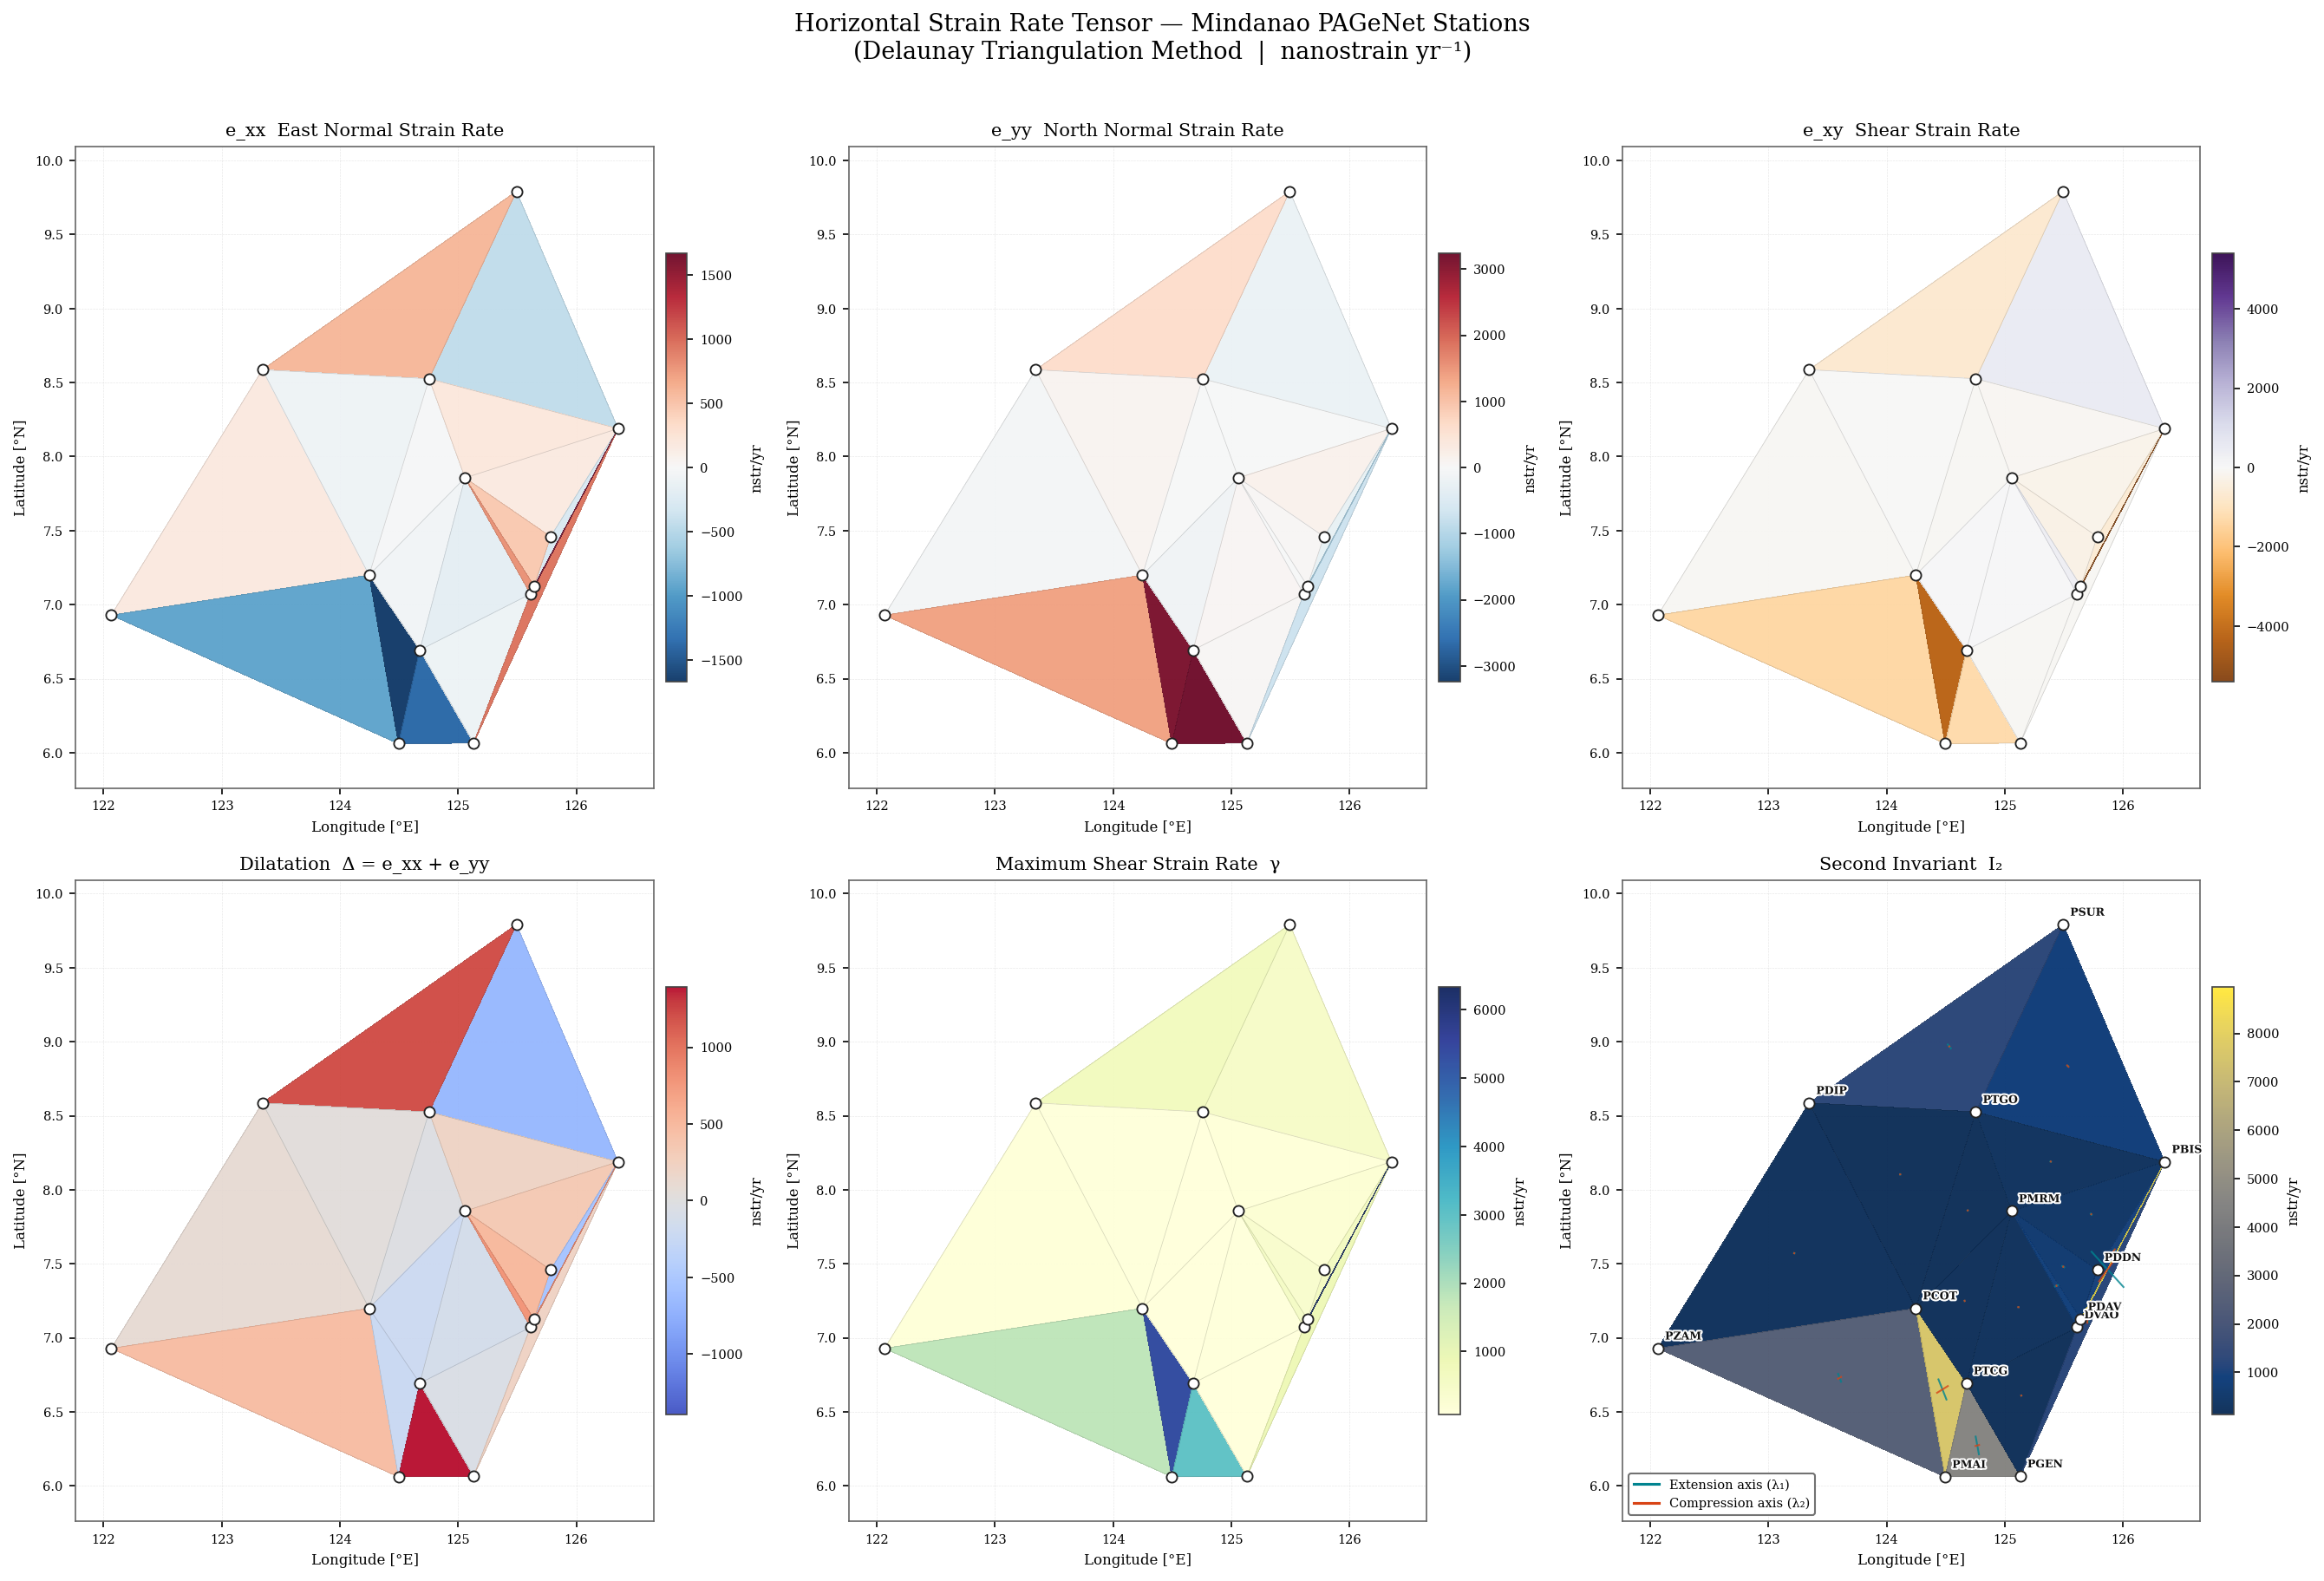

Saved: strain_map.png

── Strain summary (nanostrain/yr) ────────────────────
  epsilon_xx      min=-3340.072  max=+1912.222  mean= -86.428
  epsilon_yy      min=-1067.244  max=+3938.329  mean=+383.658
  epsilon_xy      min=-11884.385  max=+479.739  mean=-1117.457
  dilatation      min=-658.189  max=+2566.921  mean=+297.230
  max_shear       min= +57.265  max=+11977.392  mean=+1476.709
  second_inv      min=+116.927  max=+16949.124  mean=+2170.888


In [49]:
import matplotlib.patheffects as pe
from matplotlib.colors import TwoSlopeNorm, Normalize
from matplotlib.cm import ScalarMappable
from scipy.spatial import Delaunay
from matplotlib.lines import Line2D
import matplotlib.tri as mtri

# ── Load data ───────────────────────────────────
try:
    st = station_strain.copy()
    print("Using station_strain from memory.")
except NameError:
    st = pd.read_csv("gnss_strain_per_station.csv")
    print("Loaded gnss_strain_per_station.csv from disk.")

vt = pd.read_csv("gnss_velocity_table.csv")

lons_st  = vt['longitude'].values
lats_st  = vt['latitude'].values
Ve_st    = vt['Ve_est'].values
Vn_st    = vt['Vn_est'].values
sites_st = vt['site'].values

# ── Delaunay triangulation strain computation ───────────────────
print("Computing strain via Delaunay triangulation ...")

R_EARTH       = 6_371_000.0
lat_mean_rad  = np.deg2rad(np.mean(lats_st))
m_per_deg_lat = np.pi * R_EARTH / 180.0
m_per_deg_lon = m_per_deg_lat * np.cos(lat_mean_rad)

# Convert station coordinates to metres
x_m = lons_st * m_per_deg_lon
y_m = lats_st * m_per_deg_lat

points    = np.column_stack([x_m, y_m])
tri_obj   = Delaunay(points)
simplices = tri_obj.simplices

NANO = 1e9

tri_strain = []

for simp in simplices:
    i0, i1, i2 = simp

    x  = np.array([x_m[i0], x_m[i1], x_m[i2]])
    y  = np.array([y_m[i0], y_m[i1], y_m[i2]])

    ve = np.array([Ve_st[i0], Ve_st[i1], Ve_st[i2]])
    vn = np.array([Vn_st[i0], Vn_st[i1], Vn_st[i2]])

    A = np.array([
        [x[1]-x[0], x[2]-x[0]],
        [y[1]-y[0], y[2]-y[0]]
    ])

    dve = np.array([ve[1]-ve[0], ve[2]-ve[0]])
    dvn = np.array([vn[1]-vn[0], vn[2]-vn[0]])

    try:
        grad_ve = np.linalg.solve(A, dve)
        grad_vn = np.linalg.solve(A, dvn)

    except np.linalg.LinAlgError:
        tri_strain.append([np.nan]*11)
        continue

    exx = grad_ve[0]
    eyy = grad_vn[1]
    exy = 0.5 * (grad_ve[1] + grad_vn[0])

    dil   = exx + eyy
    shear = 0.5 * np.sqrt((exx - eyy)**2 + 4*exy**2)
    inv2  = np.sqrt(exx**2 + eyy**2 + 2*exy**2)

    avg  = (exx + eyy) / 2.0
    disc = np.sqrt(((exx - eyy)/2.0)**2 + exy**2)

    l1 = avg + disc
    l2 = avg - disc

    az = (
        90.0 -
        np.degrees(0.5 * np.arctan2(2*exy, exx-eyy))
    ) % 180

    clon = np.mean(lons_st[simp])
    clat = np.mean(lats_st[simp])

    tri_strain.append([
        exx*NANO,
        eyy*NANO,
        exy*NANO,
        dil*NANO,
        shear*NANO,
        inv2*NANO,
        l1*NANO,
        l2*NANO,
        az,
        clon,
        clat,
    ])

tri_df = pd.DataFrame(
    tri_strain,
    columns=[
        'epsilon_xx',
        'epsilon_yy',
        'epsilon_xy',
        'dilatation',
        'max_shear',
        'second_inv',
        'lambda1',
        'lambda2',
        'principal_az',
        'clon',
        'clat',
    ]
).dropna()

print(f"  {len(tri_df)} triangles computed.")

print(
    f"  second_inv range: "
    f"{tri_df['second_inv'].min():.3f} → "
    f"{tri_df['second_inv'].max():.3f} "
    f"nanostrain/yr"
)

# ── Triangulation object ───────────────────────────────────
mpl_tri = mtri.Triangulation(
    lons_st,
    lats_st,
    simplices
)

# ── Figure setup ───────────────────────────────────
FIELDS = [
    ('epsilon_xx', 'e_xx  East Normal Strain Rate',   'RdBu_r',  True),
    ('epsilon_yy', 'e_yy  North Normal Strain Rate',  'RdBu_r',  True),
    ('epsilon_xy', 'e_xy  Shear Strain Rate',         'PuOr',    True),
    ('dilatation', 'Dilatation  Δ = e_xx + e_yy',    'coolwarm', True),
    ('max_shear',  'Maximum Shear Strain Rate  γ',   'YlGnBu',  False),
    ('second_inv', 'Second Invariant  I₂',            'cividis', False),
]

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

fig.patch.set_facecolor('white')

axes = axes.ravel()

for ax, (key, title, cmap, diverging) in zip(axes, FIELDS):

    ax.set_facecolor('white')

    vals = tri_df[key].values

    # Robust limits
    vlo, vhi = np.percentile(vals, 5), np.percentile(vals, 95)

    if diverging:
        vlim = max(abs(vlo), abs(vhi))

        norm = TwoSlopeNorm(
            vmin=-vlim,
            vcenter=0,
            vmax=vlim
        )

    else:
        norm = Normalize(
            vmin=max(0, vlo),
            vmax=vhi
        )

    # Main strain field
    tc = ax.tripcolor(
        mpl_tri,
        facecolors=vals,
        norm=norm,
        cmap=cmap,
        shading='flat',
        alpha=0.92,
        zorder=2
    )

    # Triangle edges
    ax.triplot(
        mpl_tri,
        color='#666666',
        lw=0.35,
        alpha=0.28,
        zorder=3
    )

    # ── Principal strain axes ────────────────────────────────
    if key == 'second_inv':

        az_rad  = np.deg2rad(tri_df['principal_az'].values)

        L_scale = 0.18

        L1 = tri_df['lambda1'].abs().values
        L2 = tri_df['lambda2'].abs().values

        L1_norm = L1 / (L1.max() + 1e-12) * L_scale
        L2_norm = L2 / (L2.max() + 1e-12) * L_scale * 0.6

        dx1 = np.sin(az_rad) * L1_norm
        dy1 = np.cos(az_rad) * L1_norm

        dx2 = np.cos(az_rad) * L2_norm
        dy2 = -np.sin(az_rad) * L2_norm

        cx = tri_df['clon'].values
        cy = tri_df['clat'].values

        # Extension axis
        for i in range(len(cx)):

            ax.plot(
                [cx[i]-dx1[i], cx[i]+dx1[i]],
                [cy[i]-dy1[i], cy[i]+dy1[i]],
                color='#00838f',
                lw=1.0,
                alpha=0.8,
                zorder=4
            )

        # Compression axis
        for i in range(len(cx)):

            ax.plot(
                [cx[i]-dx2[i], cx[i]+dx2[i]],
                [cy[i]-dy2[i], cy[i]+dy2[i]],
                color='#d84315',
                lw=1.0,
                alpha=0.8,
                zorder=4
            )

    # ── Station markers ──────────────────────────────
    ax.scatter(
        lons_st,
        lats_st,
        s=34,
        color='white',
        edgecolors='#222222',
        linewidths=0.9,
        zorder=5
    )

    # Station labels
    if key == 'second_inv':

        for i, sid in enumerate(sites_st):

            ax.text(
                lons_st[i] + 0.06,
                lats_st[i] + 0.06,
                sid,
                fontsize=6,
                color='#111111',
                fontweight='bold',
                zorder=6,
                path_effects=[
                    pe.withStroke(
                        linewidth=2,
                        foreground='white'
                    )
                ]
            )

    # ── Colorbar ───────────────────────────────────
    cbar = fig.colorbar(
        tc,
        ax=ax,
        fraction=0.035,
        pad=0.02
    )

    unit = '°' if key == 'principal_az' else 'nstr/yr'

    cbar.set_label(
        unit,
        color='black',
        fontsize=8
    )

    cbar.ax.yaxis.set_tick_params(
        color='black',
        labelsize=7
    )

    plt.setp(
        cbar.ax.yaxis.get_ticklabels(),
        color='black'
    )

    cbar.outline.set_edgecolor('#444444')

    # ── Titles & axes ───────────────────────────────────
    ax.set_title(
        title,
        color='black',
        fontsize=10,
        pad=6
    )

    ax.set_xlabel(
        'Longitude [°E]',
        color='black',
        fontsize=8
    )

    ax.set_ylabel(
        'Latitude [°N]',
        color='black',
        fontsize=8
    )

    ax.tick_params(
        colors='black',
        labelsize=7
    )

    for spine in ax.spines.values():
        spine.set_edgecolor('#666666')

    ax.set_xlim(
        lons_st.min()-0.3,
        lons_st.max()+0.3
    )

    ax.set_ylim(
        lats_st.min()-0.3,
        lats_st.max()+0.3
    )

    ax.grid(
        color='#999999',
        lw=0.3,
        alpha=0.25,
        linestyle='--'
    )

# ── Legend ───────────────────────────────────
legend_elements = [
    Line2D(
        [0], [0],
        color='#00838f',
        lw=1.5,
        label='Extension axis (λ₁)'
    ),
    Line2D(
        [0], [0],
        color='#d84315',
        lw=1.5,
        label='Compression axis (λ₂)'
    ),
]

axes[5].legend(
    handles=legend_elements,
    loc='lower left',
    fontsize=7,
    framealpha=0.92,
    facecolor='white',
    edgecolor='#666666',
    labelcolor='black'
)

# ── Main title ───────────────────────────────────
fig.suptitle(
    'Horizontal Strain Rate Tensor — Mindanao PAGeNet Stations\n'
    '(Delaunay Triangulation Method  |  nanostrain yr⁻¹)',
    color='black',
    fontsize=13,
    y=1.01,
)

plt.tight_layout()

plt.savefig(
    'strain_map.png',
    dpi=220,
    bbox_inches='tight',
    facecolor='white'
)

plt.show()

print("Saved: strain_map.png")

# ── Summary ─────────────────────────────
print("\n── Strain summary (nanostrain/yr) ────────────────────")

for col in [
    'epsilon_xx',
    'epsilon_yy',
    'epsilon_xy',
    'dilatation',
    'max_shear',
    'second_inv'
]:

    print(
        f"  {col:14s}  "
        f"min={tri_df[col].min():+8.3f}  "
        f"max={tri_df[col].max():+8.3f}  "
        f"mean={tri_df[col].mean():+8.3f}"
    )

## BLOCK 20: FINAL SUMMARY

In [50]:
print("█" * 60)
print("  PIPELINE COMPLETE — ALL OUTPUTS GENERATED")
print("█" * 60)

print("\n── Regression Metrics Summary ──────────────────────────")
# Using R2 instead of R² to match column naming in metrics_df
if not metrics_df.empty:
    cols_to_show = [c for c in ['RMSE', 'MAE', 'R2'] if c in metrics_df.columns]
    display(metrics_df.pivot_table(
        index='Model', columns='Component', values=cols_to_show
    ).round(5))

print("\n── Additional Pipeline Steps ──────────────────────────")
print("  ✓  **Visualizations:** Generated plots for Actual vs. Estimated Velocities, Residual Distributions, and Model Comparison.")
print("  ✓  **Best Model Selection:** Identified the best performing model (based on R²) to re-estimate velocities for all stations.")
print("  ✓  **Site Summary & Data Gaps:** Created a comprehensive summary of site data, including re-calculating velocities for sites previously excluded due to insufficient epochs using linear regression.")
print("  ✓  **Time Series Graphs:** Generated per-site East/North displacement time series plots.")
print("  ✓  **Spatial Interpolation & Geodetic Table:** Exported a geodetic velocity table, converting units to mm/yr, and prepared data for spatial analysis.")
print("  ✓  **Velocity Field Map:** Visualized the GNSS horizontal velocity field on a map of Mindanao.")
print("  ✓  **Strain Tensor Computation:** Computed various strain tensor components (e.g., dilatation, maximum shear, second invariant) using spatial interpolation and sampled them at station coordinates.")
print("  ✓  **Strain Maps:** Visualized the computed strain rates using Delaunay triangulation.")


print("\n── Files Saved ──────────────────────────────────────────")
output_files = [
    "preprocessed_gnss_data.csv",
    "regression_metrics.csv",
    "classification_diagnostics.csv",
    "strain_tensor_grids.npz",
    "rf_feature_importance.png",
    "lstm_training_curves.png",
    "actual_vs_estimated.png",
    "residual_distributions.png",
    "model_comparison.png",
    "velocity_field_map.png",
    "strain_maps.png",
]
for f in output_files:
    print(f"  ✓  {f}")

████████████████████████████████████████████████████████████
  PIPELINE COMPLETE — ALL OUTPUTS GENERATED
████████████████████████████████████████████████████████████

── Regression Metrics Summary ──────────────────────────


MAE                R2              RMSE         
Component           Ve       Vn       Ve       Vn       Ve       Vn
Model                                                              
LSTM           0.02216  0.02361  0.18291 -0.32925  0.03388  0.03122
Random Forest  0.00760  0.00430  0.48828  0.85442  0.02674  0.01032
SVR            0.00577  0.00416  0.48589  0.90864  0.02680  0.00818


── Additional Pipeline Steps ──────────────────────────
  ✓  **Visualizations:** Generated plots for Actual vs. Estimated Velocities, Residual Distributions, and Model Comparison.
  ✓  **Best Model Selection:** Identified the best performing model (based on R²) to re-estimate velocities for all stations.
  ✓  **Site Summary & Data Gaps:** Created a comprehensive summary of site data, including re-calculating velocities for sites previously excluded due to insufficient epochs using linear regression.
  ✓  **Time Series Graphs:** Generated per-site East/North displacement time series plots.
  ✓  **Spatial Interpolation & Geodetic Table:** Exported a geodetic velocity table, converting units to mm/yr, and prepared data for spatial analysis.
  ✓  **Velocity Field Map:** Visualized the GNSS horizontal velocity field on a map of Mindanao.
  ✓  **Strain Tensor Computation:** Computed various strain tensor components (e.g., dilatation, maximum shear, second invariant) using spatial interpolat